# 3. Exploratory Data Analysis (EDA)

## 3.1. Discovering data distribution

First step, is the loading the cleaned dataset from previous step.

In [71]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import seaborn as sns 
import numpy as np 
import pandas as pd
from pathlib import Path

#Optional (For Github)
#pio.renderers.default = "svg"

In [72]:
project_root = Path.cwd().parent
raw_data_directory_path = project_root / "data" / "raw"
processed_data_directory_path = project_root / "data" / "processed"

In [73]:
df = pd.read_csv(processed_data_directory_path / "e-commerce-data-cleaned.csv", encoding = "ISO-8859-1")
df

,invoice_number,stock_code,description,quantity,invoice_datetime,invoice_date,invoice_time,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2010-12-01,08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,2010-12-01,08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2010-12-01,08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,2010-12-01,08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,2010-12-01,08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...,...,...
391063,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,2011-12-09,12:50:00,0.85,12680.0,France
391064,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2011-12-09,12:50:00,2.10,12680.0,France
391065,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,2011-12-09,12:50:00,4.15,12680.0,France
391066,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,2011-12-09,12:50:00,4.15,12680.0,France


The initial phase of the EDA process in this project will involve constructing the plot distribution across variables. Firstly, the following will be analysed based on with the nature of the variable data:
1. *customer_id* - to see the distribution of customers' activity;
2. *stock_code* - to see the distribution of how often the specific good or group of goods is ordered;
3. *invoice_datetime* and *invoice_date* - to analyse the distribution of orders by date and time, and identify the most active periods;
4. *country* - to analyse the the most active clients by country.

Perhaps the following could be tried:
1. Group the *quantity* column into several order size categories, such as “small order,” “medium order,” and “large order.” Then visualize the distribution across these categories.
2. Group the *customer_id* column into several categories based on customer activity, maybe create bins of the number of orders, for example, "< 10" orders, "10-15", and so on. Then visualize the distribution of histogram for this bins.

### 3.1.1. Distribution of *customer_id*
First, start with the *customer_id*, build the distribution chart to understand the pattern of customer activity.

For this, first, determine how many times each customer (*customer_id*) appears in the dataset.

In [74]:
idx = pd.Index(df['customer_id'])
customer_counts = idx.value_counts()
customer_counts

customer_id
17841.0    7667
14911.0    5584
14096.0    5095
12748.0    4397
14606.0    2674
           ... 
18184.0       1
13188.0       1
13017.0       1
18174.0       1
15195.0       1
Name: count, Length: 4334, dtype: int64

Once the new data has been received, it becomes possible to examine the summary statistics for the *customer_id* column. This procedure was performed earlier, but now it is being done on the cleaned data.

In [75]:
customer_counts.describe().T

count    4334.000000
mean       90.232580
std       224.707914
min         1.000000
25%        17.000000
50%        41.000000
75%        98.000000
max      7667.000000
Name: count, dtype: float64

For a more accurate analysis, we also calculate the summary statistics for the column in its original format.

In [76]:
df['customer_id'].describe().T

count    391068.000000
mean      15295.134849
std        1710.345760
min       12346.000000
25%       13969.000000
50%       15158.000000
75%       16794.000000
max       18287.000000
Name: customer_id, dtype: float64

Since the data was imported as numeric values again, the data in this column is being converted to the `object` format.

In [77]:
df['customer_id'] = df['customer_id'].astype('object')
df['customer_id'].describe(include = 'object').T

count     391068.0
unique      4334.0
top        17841.0
freq        7667.0
Name: customer_id, dtype: float64

As is evident, even following the process of data cleansing, the distribution remains skewed, as there are still users with abnormally high activity levels. For instance, customer with ID $17841$ has an activity frequency of $7667$, which differs significantly from both the mean and the median.

To determine whether this is an outlier and if there are other similar customers, as previously mentioned, it is necessary to plot a distribution graph. To begin the distribution analysis, it is good to start with around $25$ bins.

In [78]:
customer_mean = np.mean(customer_counts)
customer_std = np.std(customer_counts)

print("mean =", customer_mean, "\nstd = ", customer_std)

mean = 90.23257960313798 
std =  224.68198905716025


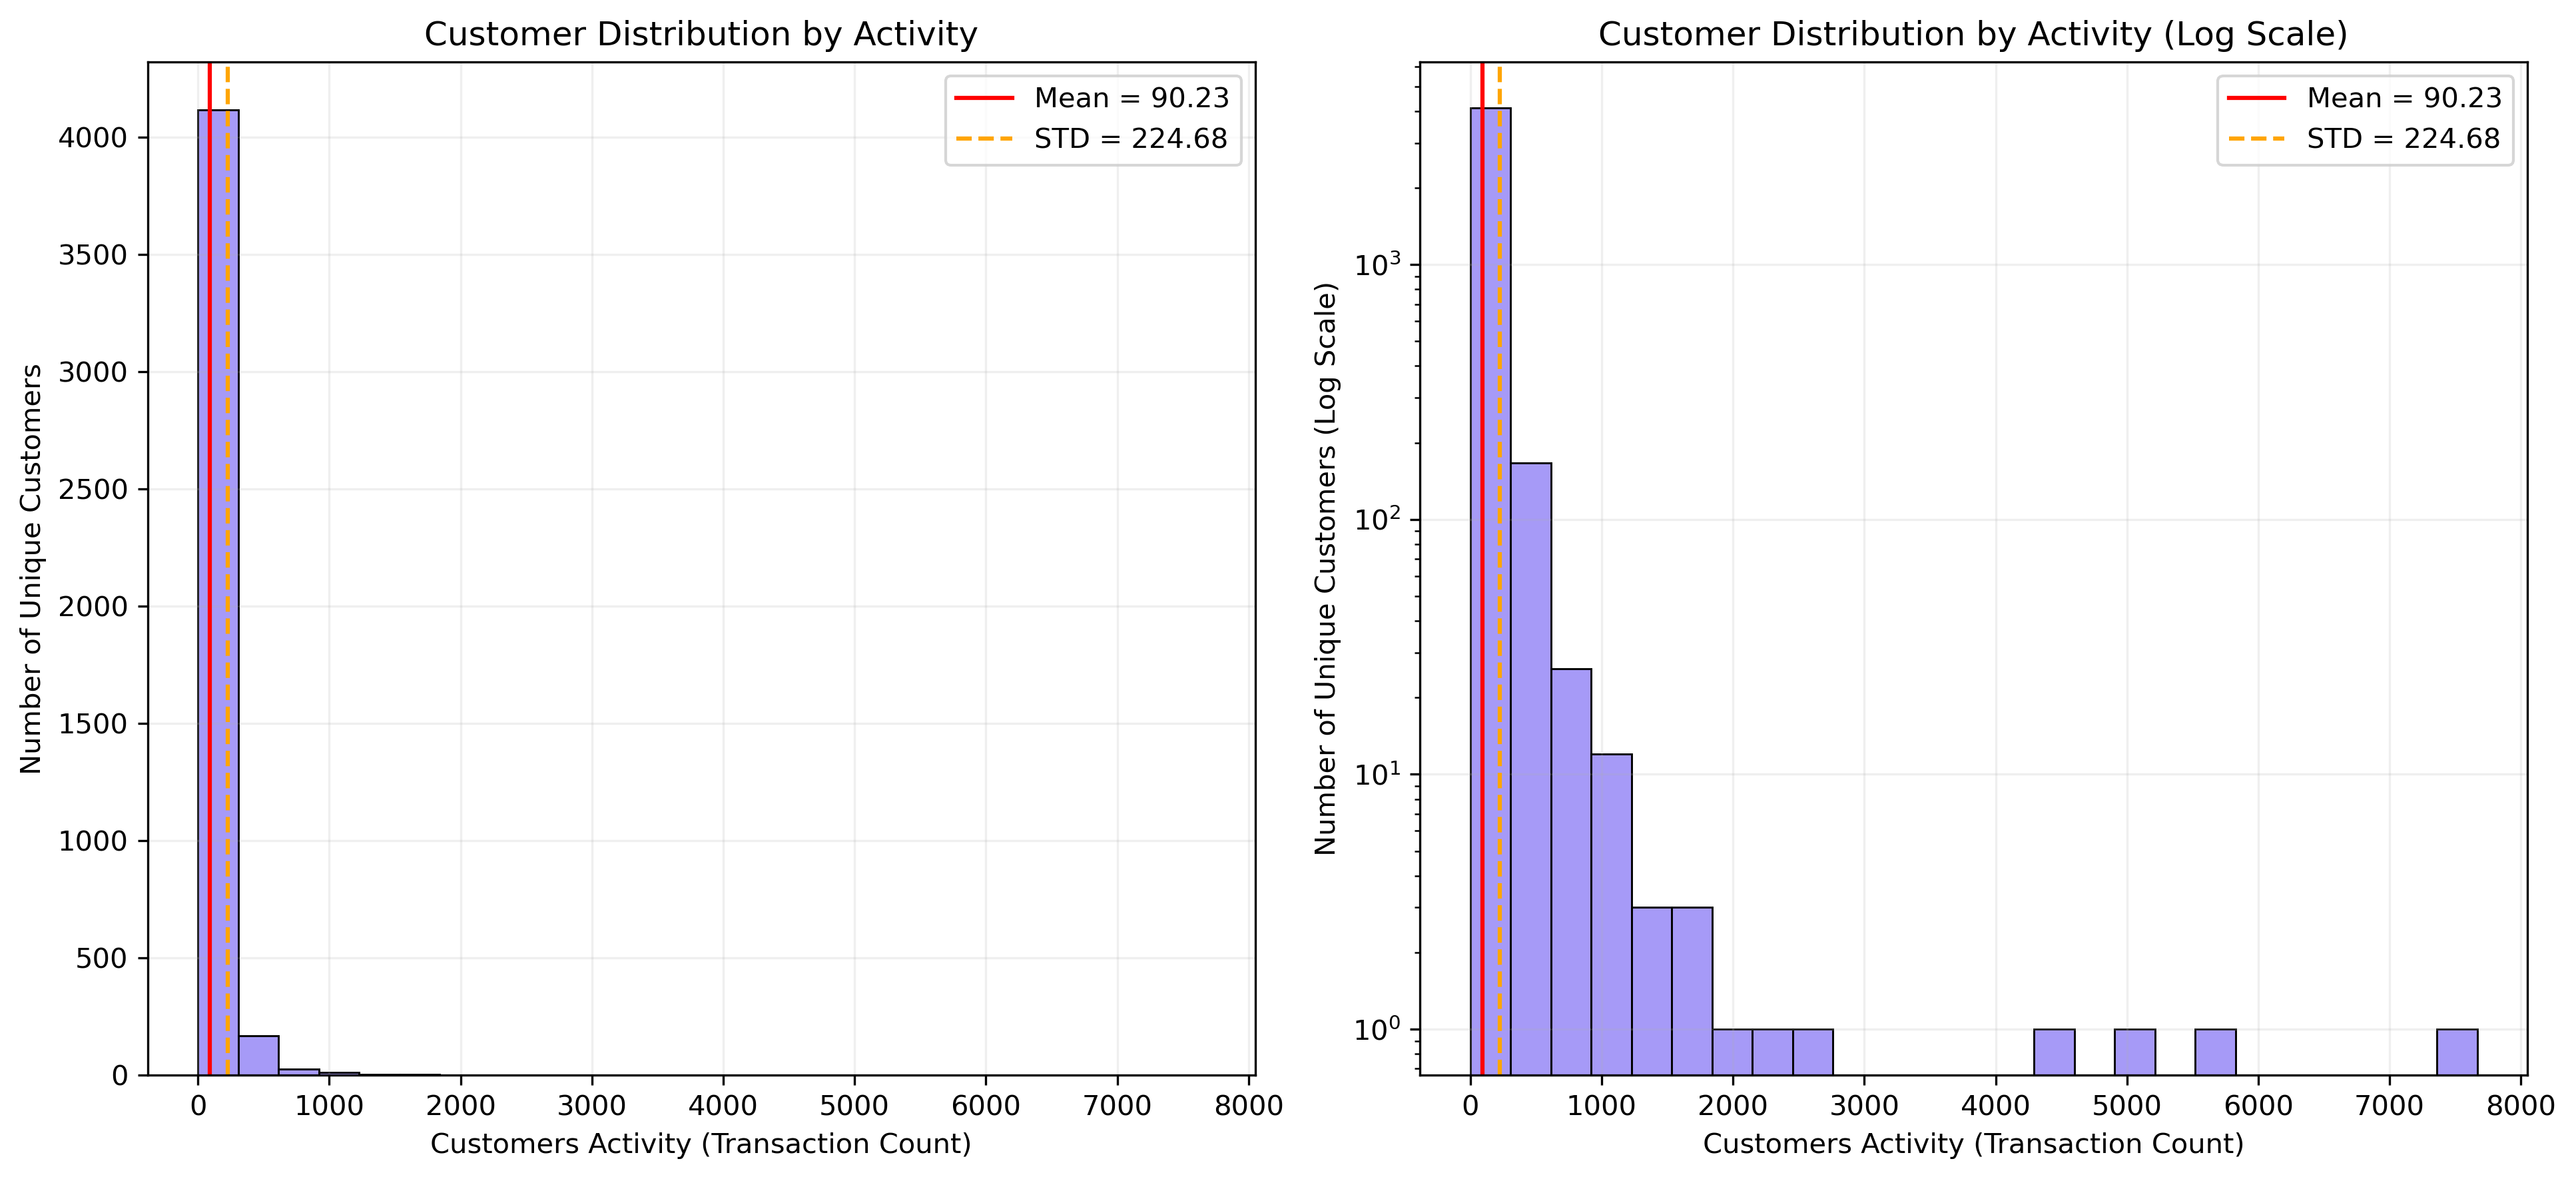

In [79]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (13, 6), dpi = 300)

#============ Plot 1 ==========
sns.histplot(customer_counts, bins = 25, ax = ax1, color = '#8978f5', edgecolor = 'black', linewidth = 0.7)
ax1.axvline(customer_mean, color = 'red', label = f'Mean = {customer_mean:.2f}')
ax1.axvline(customer_std, color = 'orange', ls = '--', label = f'STD = {customer_std:.2f}')

ax1.set_title('Customer Distribution by Activity')
ax1.set_xlabel('Customers Activity (Transaction Count)')
ax1.set_ylabel('Number of Unique Customers')
ax1.legend()
ax1.grid(alpha = 0.2)

#============ Plot 2 ==========
sns.histplot(customer_counts, bins = 25, ax = ax2, color = '#8978f5', edgecolor = 'black', linewidth = 0.7)
ax2.axvline(customer_mean, color = 'red', label = f'Mean = {customer_mean:.2f}')
ax2.axvline(customer_std, color = 'orange', ls = '--', label = f'STD = {customer_std:.2f}')

ax2.set_yscale('log')

ax2.set_title('Customer Distribution by Activity (Log Scale)')
ax2.set_xlabel('Customers Activity (Transaction Count)')
ax2.set_ylabel('Number of Unique Customers (Log Scale)')
ax2.legend()
ax2.grid(alpha = 0.2)


plt.tight_layout() # Prevents labels from overlapping
plt.show()

At this stage, all data points are assumed to be important and valid. But to assess the distribution in greater detail, the interquartile range and the lower and upper thresholds will be calculated. Data points beyond these thresholds are classified as outliers and are subject to winsorization. Based on the results of the winsorization, a decision will be made on how to handle outliers.

To get the lower and upper thresholds the more robust and common way is to use the interquartile range and multiply it by $1.5$. Then this result is subtracted from the $25th$ percentile and added to the $75th$. This can be expressed using the following equations:

$$Lower\_threshold = 25\_percentile - (1.5 * IQR)$$
$$Upper\_threshold = 75\_percentile + (1.5 * IQR)$$

where:

$$IQR = 75\_percentile - 25\_percentile$$

In [80]:
customer_25_percentile = np.percentile(customer_counts, 25)
customer_75_percentile = np.percentile(customer_counts, 75)

customer_IQR = customer_75_percentile - customer_25_percentile

customer_lower_threshold = customer_25_percentile - (1.5 * customer_IQR)
customer_upper_threshold = customer_75_percentile + (1.5 * customer_IQR)

print("Parameters for identifying outliers")
print("\n25 percentile =", customer_25_percentile,
      "\n75 percentile =", customer_75_percentile,
      "\nIQR =", customer_IQR,
      "\nLower threshold =", customer_lower_threshold,
      "\nUpper threshold =", customer_upper_threshold)

Parameters for identifying outliers

25 percentile = 17.0 
75 percentile = 98.0 
IQR = 81.0 
Lower threshold = -104.5 
Upper threshold = 219.5


As the IQR was calculated. The optimal number of bins by the **Freedman-Diaconis rule** could be obtained. The rule is written as follows:

$$Bin\ Width = \frac{2 \times IQR}{n^{1/3}}$$
$$Number\ of\ Bins = \frac{Range}{Bin\ Width}$$

In [81]:
bw = (2 * customer_IQR) / pow(len(customer_counts), 1/3)
customer_bins = (customer_counts.max() - customer_counts.min()) / bw
print (f"Optimal number of bins = {customer_bins:.1f}")

Optimal number of bins = 771.5


However, due to the long tail of the data distribution, the number of bins obtained ($771$) is extremely large and cannot be applied. According to this, the number of bins remains at $25$.

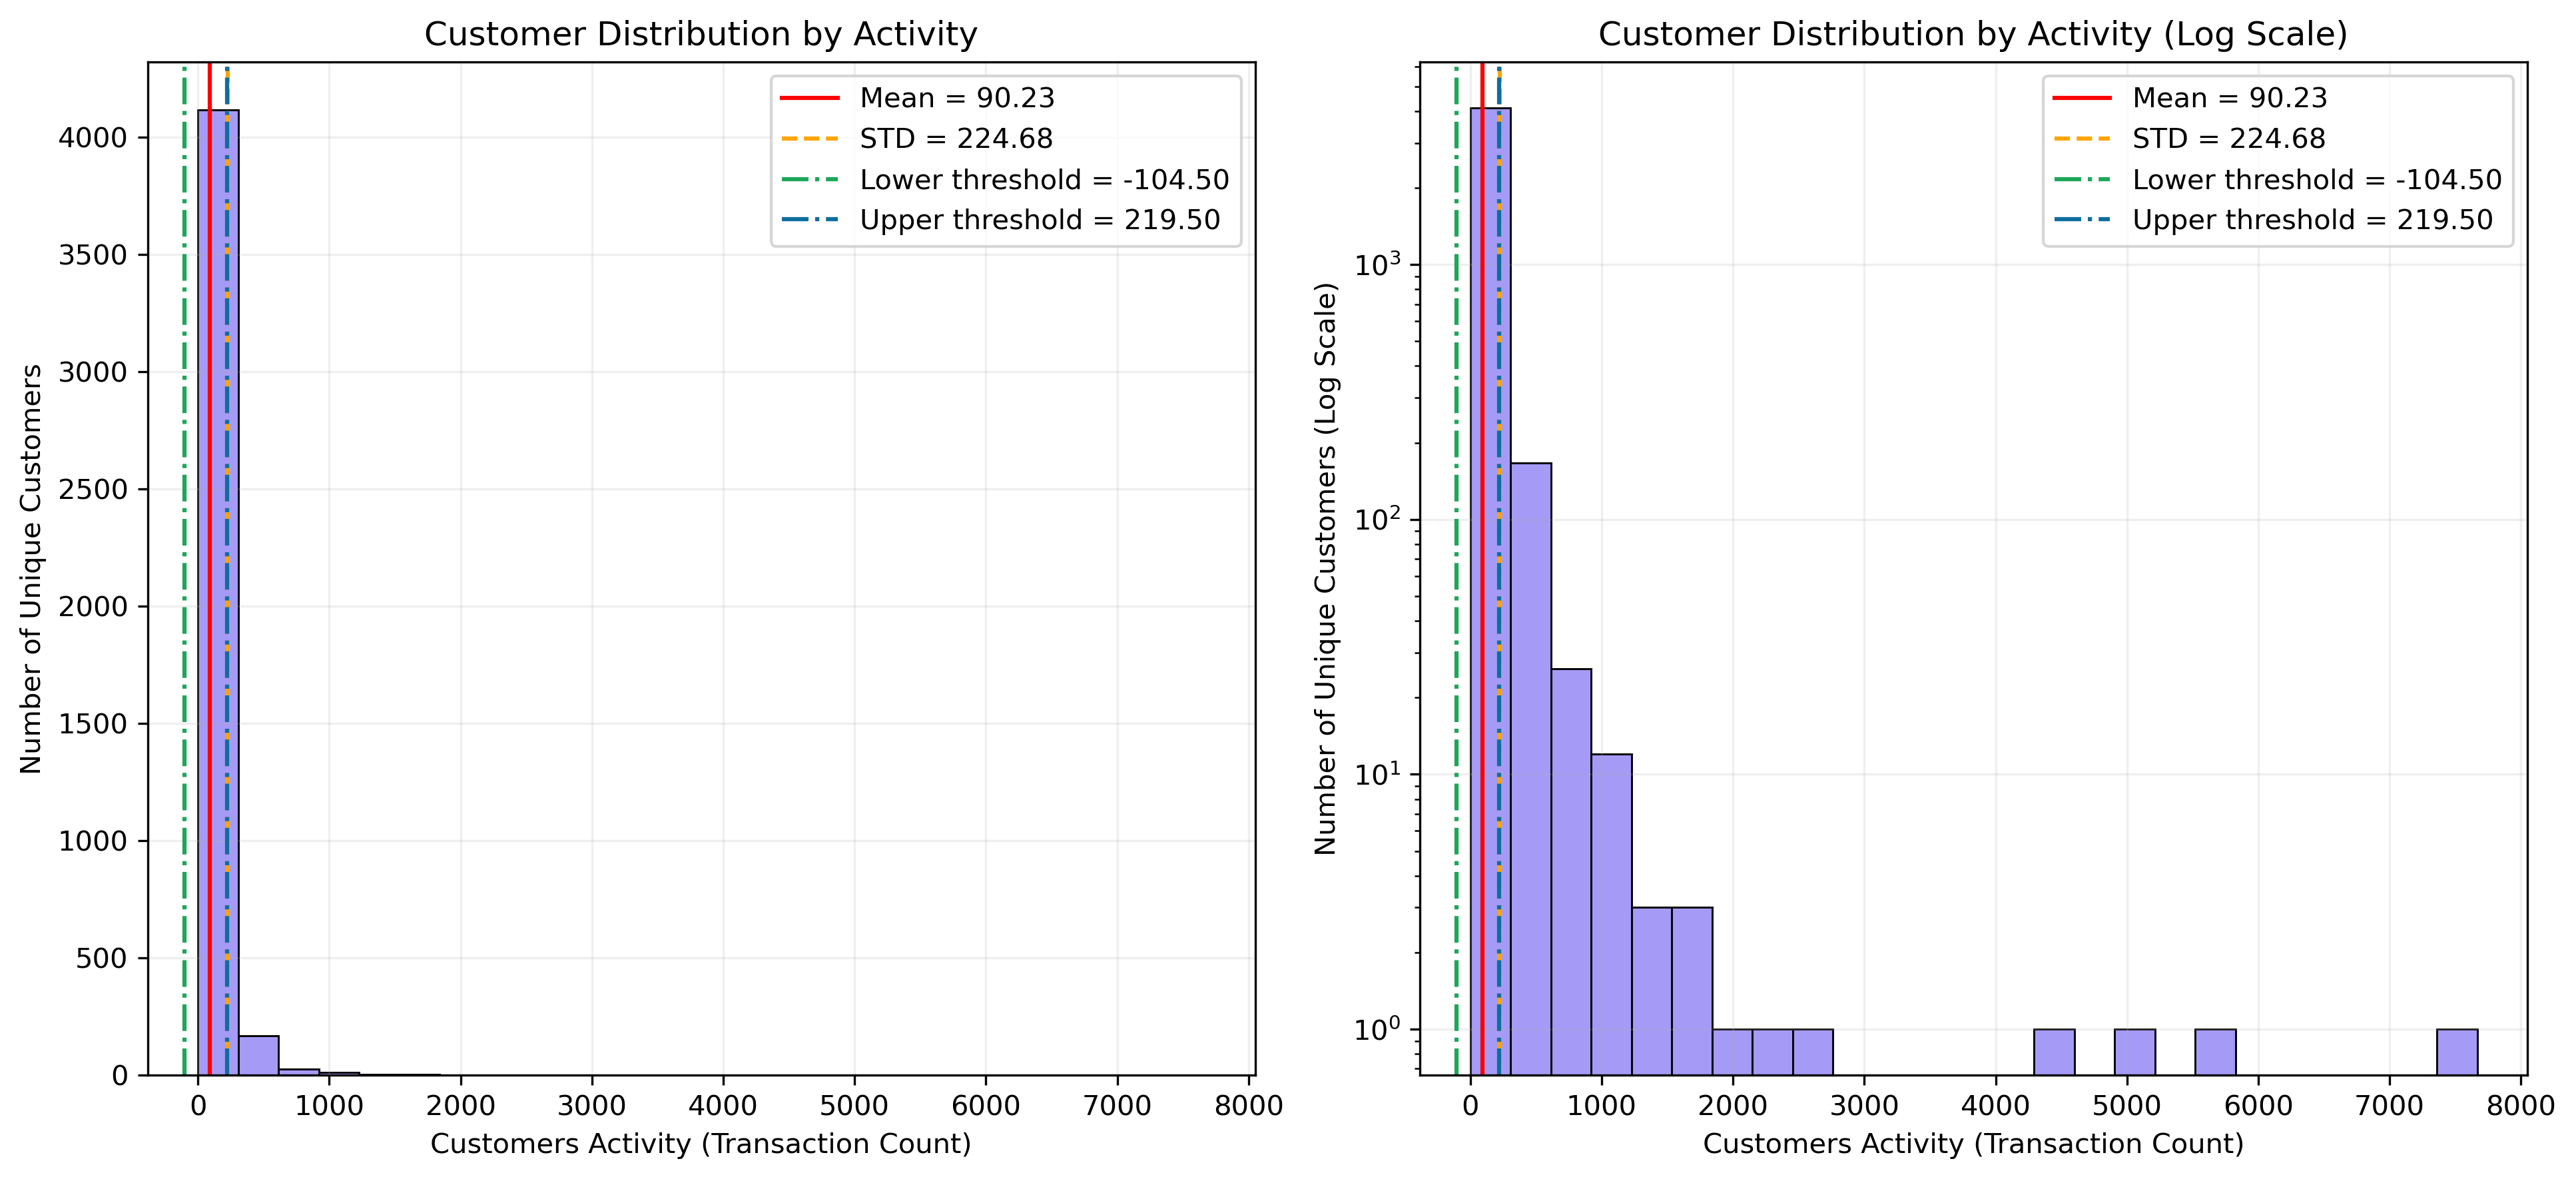

In [82]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (13, 6), dpi = 300)

#============ Plot 1 ==========
sns.histplot(customer_counts, bins = 25, ax = ax1, color = '#8978f5', edgecolor = 'black', linewidth = 0.7)
ax1.axvline(customer_mean, color = 'red', label = f'Mean = {customer_mean:.2f}')
ax1.axvline(customer_std, color = 'orange', ls = '--', label = f'STD = {customer_std:.2f}')
ax1.axvline(customer_lower_threshold, color = '#1ea659', ls = '-.', label = f'Lower threshold = {customer_lower_threshold:.2f}')
ax1.axvline(customer_upper_threshold, color = '#0d6e9e', ls = '-.', label = f'Upper threshold = {customer_upper_threshold:.2f}')

ax1.set_title('Customer Distribution by Activity')
ax1.set_xlabel('Customers Activity (Transaction Count)')
ax1.set_ylabel('Number of Unique Customers')
ax1.legend()
ax1.grid(alpha = 0.2)

#============ Plot 2 ==========
sns.histplot(customer_counts, bins = 25, ax = ax2, color = '#8978f5', edgecolor = 'black', linewidth = 0.7)
ax2.axvline(customer_mean, color = 'red', label = f'Mean = {customer_mean:.2f}')
ax2.axvline(customer_std, color = 'orange', ls = '--', label = f'STD = {customer_std:.2f}')
ax2.axvline(customer_lower_threshold, color = '#1ea659', ls = '-.', label = f'Lower threshold = {customer_lower_threshold:.2f}')
ax2.axvline(customer_upper_threshold, color = '#0d6e9e', ls = '-.', label = f'Upper threshold = {customer_upper_threshold:.2f}')

ax2.set_yscale('log')

ax2.set_title('Customer Distribution by Activity (Log Scale)')
ax2.set_xlabel('Customers Activity (Transaction Count)')
ax2.set_ylabel('Number of Unique Customers (Log Scale)')
ax2.legend()
ax2.grid(alpha = 0.2)


plt.tight_layout() # Prevents labels from overlapping
plt.show()

As is evident, the range of data between the upper and lower thresholds is relatively limited. In order to guarantee that all details are considered in the analysis, the subsequent step is to implement the winsorization process. This involves replacing data points that fall outside the 5th and 95th percentiles with values that correspond to those percentiles. The value of $1.5$ is taken based on the **1.5 IQR** rule which, is a statistical method used for identifying outliers in a dataset.
That is:

$$ IF\ value < 5th\ percentile\ THEN\ value\ = 5th\ percentile$$
$$ IF\ value > 95th\ percentile\ THEN\ value\ = 95th\ percentile$$

The interquartile (IQR) method of outlier detection uses $1.5$ as its scale to detect outliers because it most closely follows Gaussian distribution. As a result, the method dictates that any data point that’s 1.5 points below the lower bound quartile or above the upper bound quartile is an outlier.

As the distribution graph is right-skewed in this case, there is no need to perform lower-limit winsorization.

In [83]:
upper_limit = np.percentile(customer_counts, 95)

customer_counts_winsorized = customer_counts.clip(upper = upper_limit)

customer_counts_winsorized

customer_id
17841.0    308
14911.0    308
14096.0    308
12748.0    308
14606.0    308
          ... 
18184.0      1
13188.0      1
13017.0      1
18174.0      1
15195.0      1
Name: count, Length: 4334, dtype: int64

Before plotting new graphs, the mean and median values for the updated data will be calculated.

In [84]:
ustomer_winsorized_mean = np.mean(customer_counts_winsorized)
customer_winsorized_std = np.std(customer_counts_winsorized)

print("mean =", ustomer_winsorized_mean, "\nstd = ", customer_winsorized_std)

mean = 73.81287494231657 
std =  82.3783062154595


Now, when data is winsorized, the optimal number of bins can be obtained using the **Freedman–Diaconis** rule:

In [85]:
bw = (2 * customer_IQR) / pow(len(customer_counts_winsorized), 1/3)
winsorized_customer_bins = (customer_counts_winsorized.max() - customer_counts_winsorized.min()) / bw
print (f"Optimal number of bins = {winsorized_customer_bins:.1f}")

Optimal number of bins = 30.9


Given that winsorization has relieved the outliers (extreme values) from the distribution graph, the second graph on a logarithmic scale is no longer necessary 

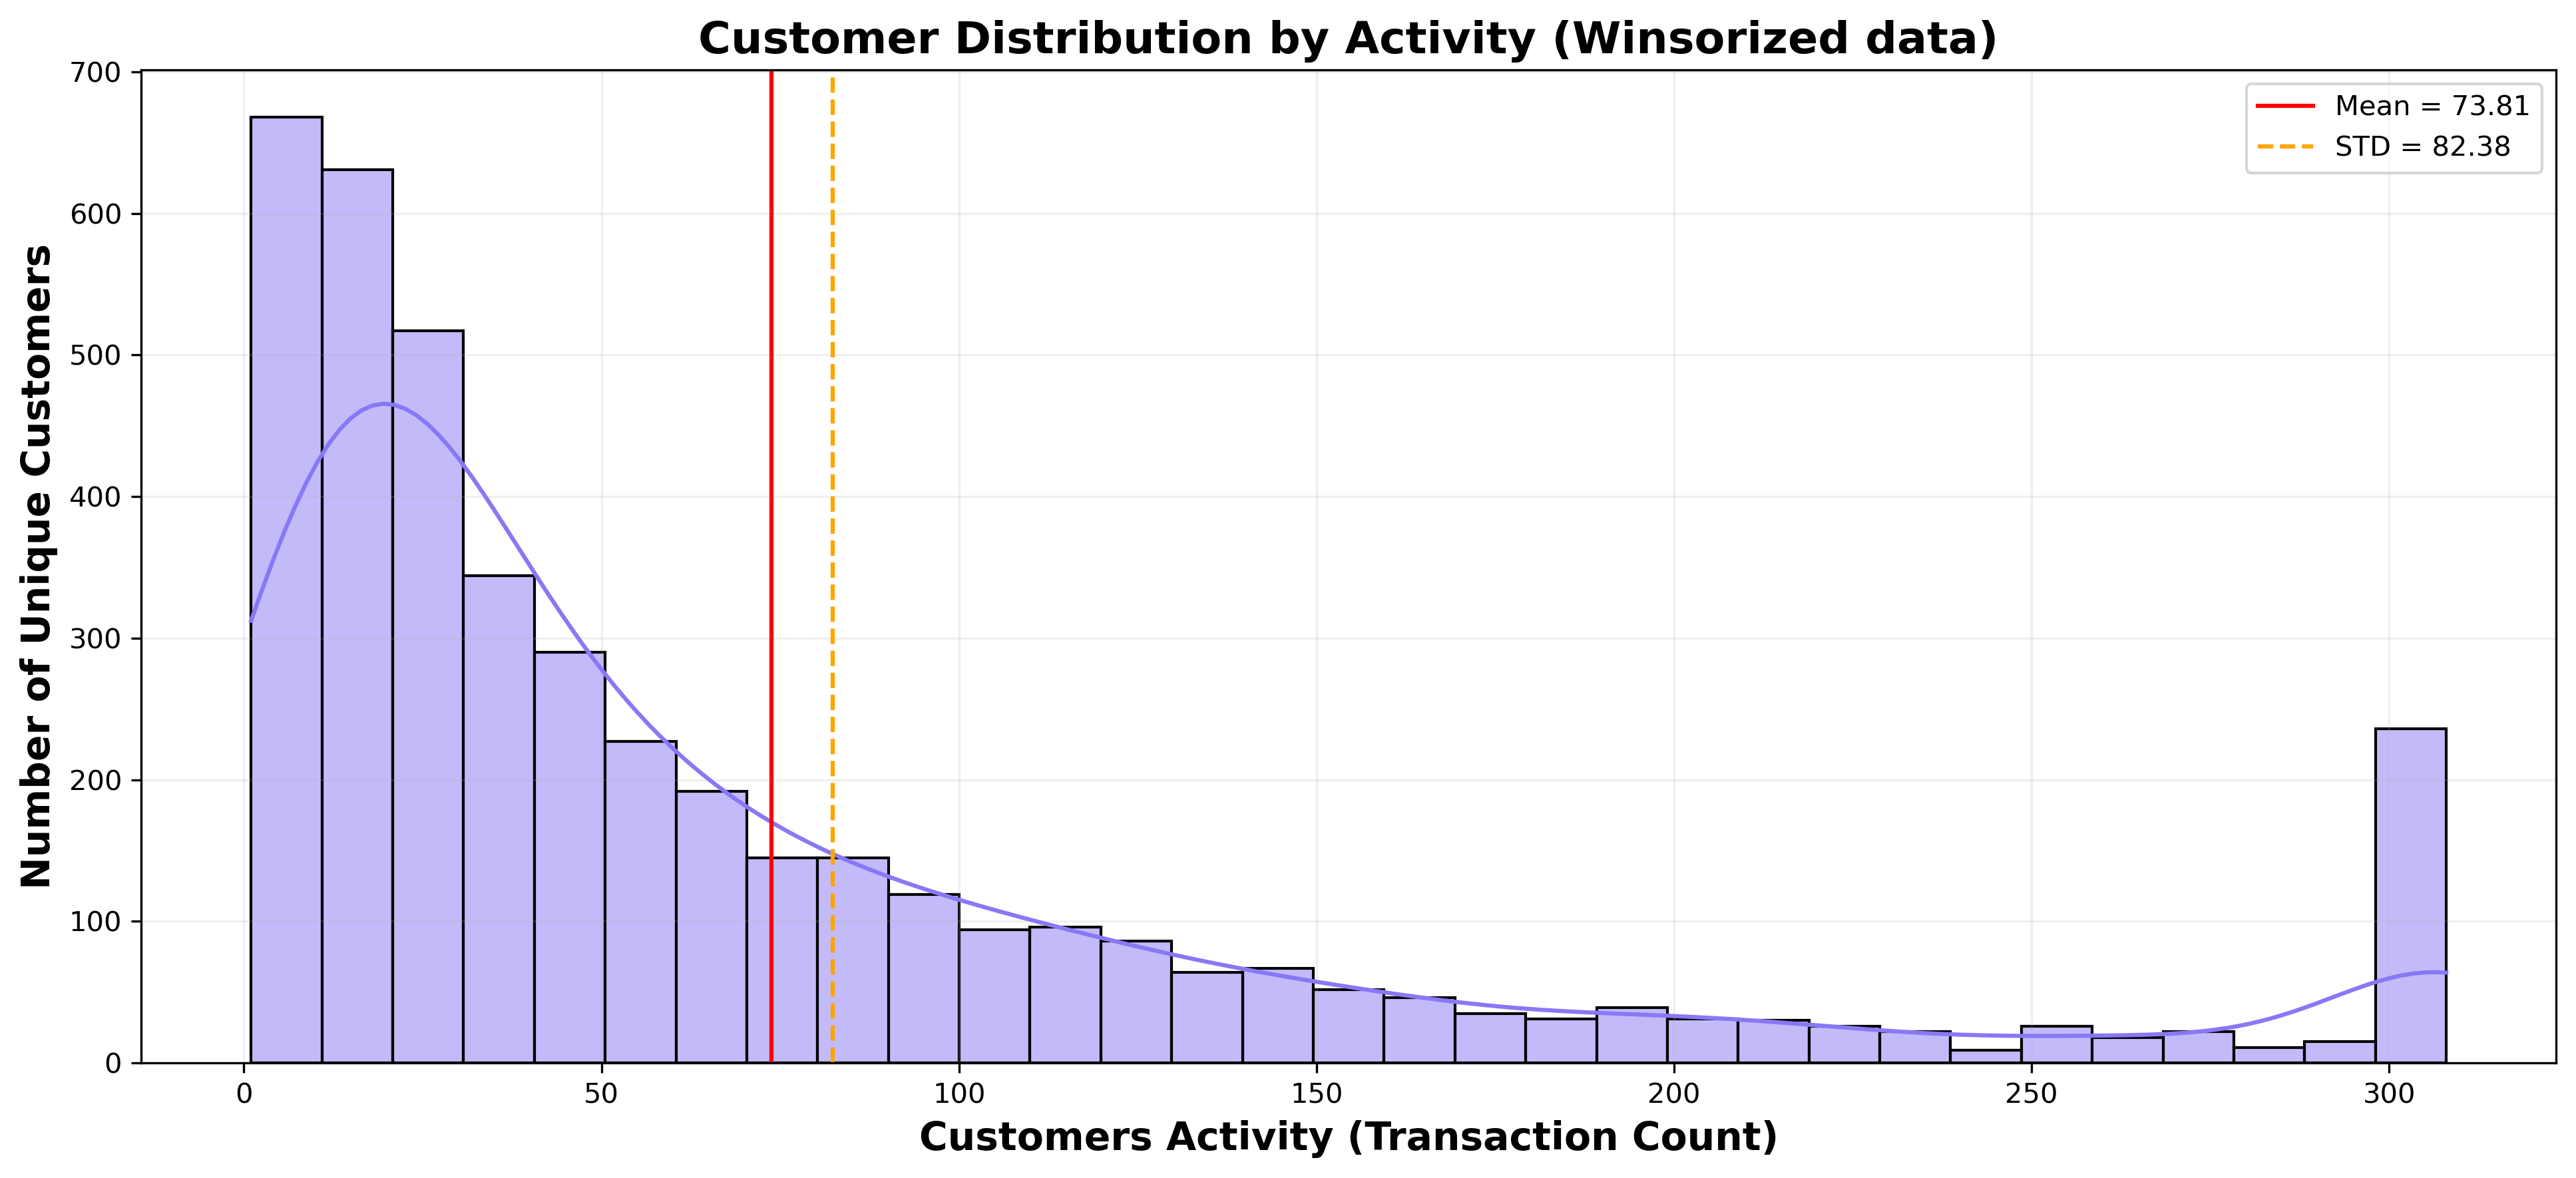

In [86]:
fig, ax = plt.subplots(figsize = (13, 6), dpi = 300)

#============ Plot 1 ==========
sns.histplot(customer_counts_winsorized, bins = 31, ax = ax, kde = True, color = '#8978f5', edgecolor = 'black', linewidth = 1)
ax.axvline(ustomer_winsorized_mean, color = 'red', label = f'Mean = {ustomer_winsorized_mean:.2f}')
ax.axvline(customer_winsorized_std, color = 'orange', ls = '--', label = f'STD = {customer_winsorized_std:.2f}')

ax.set_title('Customer Distribution by Activity (Winsorized data)', fontweight = 'bold', fontsize = 16)
ax.set_xlabel('Customers Activity (Transaction Count)', fontweight = 'bold', fontsize = 14)
ax.set_ylabel('Number of Unique Customers', fontweight = 'bold', fontsize = 14)
ax.legend()
ax.grid(alpha = 0.2)

plt.tight_layout()
plt.show()

It would be useful to know how many users underwent the winsorization process. According to the results, it was $215$ unique customers.

In [87]:
diff_mask = customer_counts != customer_counts_winsorized
changed_count = diff_mask.sum()

print(f"Number of customers subjected to winsorization: {changed_count}")

Number of customers subjected to winsorization: 215


In order to gain a more comprehensive understanding of the impact of the winsorization procedure on the statistical parameters, a comparison will be conducted between the corrected data and the original data.

In [88]:
original_stats = customer_counts.describe()
winsorized_stats = customer_counts_winsorized.describe()

# Concatenate descriptions along columns (axis=1)
comparison_df = pd.concat([original_stats, winsorized_stats], axis=1)

comparison_df.columns = ['Original Data', 'Winsorized (95th)']
print(comparison_df)

       Original Data  Winsorized (95th)
count    4334.000000        4334.000000
mean       90.232580          73.812875
std       224.707914          82.387812
min         1.000000           1.000000
25%        17.000000          17.000000
50%        41.000000          41.000000
75%        98.000000          98.000000
max      7667.000000         308.000000


As can be seen, the data has been successfully normalized. This is particularly evident when comparing the mean and median values. As a result, it was successfully analyzed how customers were distributed by activity level, while retaining data on customers with abnormally high activity and not deleting it.

As can be seen from the last graphs, the distribution of customer activity, as previously described, is right-skewed (positive asymmetry), but this conclusion is now definitively confirmed. This result indicates that the majority of clients are customers with a relatively low order frequency. For future customer segmentation, users can be divided into the following groups based on order frequency:
- **Low activity** - $0-100$;
- **Moderate activity** - $100-300$;
- **High activity** - $Over\ 300$.

The final step will be to select users who have been subject to winsorization and place them into a separate dataset that can be used later.

In [89]:
# using the upper_limit (the 95th percentile) to identify the IDs that extend beyond the upper limit
customer_counts_winsorized_ids = customer_counts[customer_counts > upper_limit].index

customer_winsorized = df[df['customer_id'].isin(customer_counts_winsorized_ids)]
customer_winsorized

,invoice_number,stock_code,description,quantity,invoice_datetime,invoice_date,invoice_time,unit_price,customer_id,country
85,536378,22386,JUMBO BAG PINK POLKADOT,10,2010-12-01 09:37:00,2010-12-01,09:37:00,1.95,14688.0,United Kingdom
86,536378,85099C,JUMBO BAG BAROQUE BLACK WHITE,10,2010-12-01 09:37:00,2010-12-01,09:37:00,1.95,14688.0,United Kingdom
87,536378,21033,JUMBO BAG CHARLIE AND LOLA TOYS,10,2010-12-01 09:37:00,2010-12-01,09:37:00,2.95,14688.0,United Kingdom
88,536378,20723,STRAWBERRY CHARLOTTE BAG,10,2010-12-01 09:37:00,2010-12-01,09:37:00,0.85,14688.0,United Kingdom
89,536378,84997B,RED 3 PIECE RETROSPOT CUTLERY SET,12,2010-12-01 09:37:00,2010-12-01,09:37:00,3.75,14688.0,United Kingdom
...,...,...,...,...,...,...,...,...,...,...
391019,581581,23562,SET OF 6 RIBBONS PERFECTLY PRETTY,6,2011-12-09 12:20:00,2011-12-09,12:20:00,2.89,17581.0,United Kingdom
391020,581581,23561,SET OF 6 RIBBONS PARTY,6,2011-12-09 12:20:00,2011-12-09,12:20:00,2.89,17581.0,United Kingdom
391021,581581,23681,LUNCH BAG RED VINTAGE DOILY,10,2011-12-09 12:20:00,2011-12-09,12:20:00,1.65,17581.0,United Kingdom
391022,581582,23552,BICYCLE PUNCTURE REPAIR KIT,6,2011-12-09 12:21:00,2011-12-09,12:21:00,2.08,17581.0,United Kingdom


In [90]:
total_customer_winsorized = customer_winsorized.shape[0]
percentage_customer_winsorized = float((total_customer_winsorized / df.shape[0]) * 100)

print(f"\nNumber of users underwent the winsorization process {total_customer_winsorized} ({percentage_customer_winsorized:.2f}%) records")


Number of users underwent the winsorization process 137383 (35.13%) records



The following results were obtained from an analysis of the distribution of parameter `cutomer_id`:
1. The activity of $215$ users was smoothed out using Winsorisation. This was because their activity levels were unusually high compared to other users, making it difficult to analyse the distribution accurately.
2. These $215$ customers account for $137383\ (35.13\%)$ transaction records in the dataset.

Saving the obtained dataset of high activity customers in a separate file for possible further use or deeper sub-EDA analysis.

In [91]:
customer_winsorized.to_csv(processed_data_directory_path / "e-commerce-data-winsorized-customer-activity.csv", index = False)

### 3.1.2. Discovering of *stock_code*

First step, determining how many times each item (*stock_code*) appears in the dataset.

In [92]:
idx = pd.Index(df['stock_code'])
stock_code_counts = idx.value_counts()
stock_code_counts

stock_code
85123A    2023
22423     1713
85099B    1615
84879     1395
47566     1389
          ... 
90214T       1
90214U       1
90214W       1
90214Z       1
23843        1
Name: count, Length: 3657, dtype: int64

After receiving new data, next examine the summary statistics for the *stock_code* column.

In [93]:
stock_code_counts.describe().T

count    3657.000000
mean      106.936833
std       161.182222
min         1.000000
25%        12.000000
50%        48.000000
75%       134.000000
max      2023.000000
Name: count, dtype: float64

As was the case with the *customer_id* column, the *stock_code* column must also be analysed as an object data type.

In [94]:
df['stock_code'].describe(include = 'object').T

count     391068
unique      3657
top       85123A
freq        2023
Name: stock_code, dtype: object

Based on the results obtained, we can confirm that the distribution of *stock_code* is skewed. Thus, the results show a high frequency of orders for the product with item code $85123A$, which amounts to $2023$. At the same time, this maximum value differs significantly from the the mean $106$, standard deviation - $161$, and the 75th percentile - $134$. Based on this, the distribution graph for *stock_code* will also be plotted using a logarithmic scale.

In [95]:
stock_code_mean = np.mean(stock_code_counts)
stock_code_std = np.std(stock_code_counts)

print("mean =", stock_code_mean, "\nstd = ", stock_code_std)

mean = 106.93683347005742 
std =  161.16018252717842


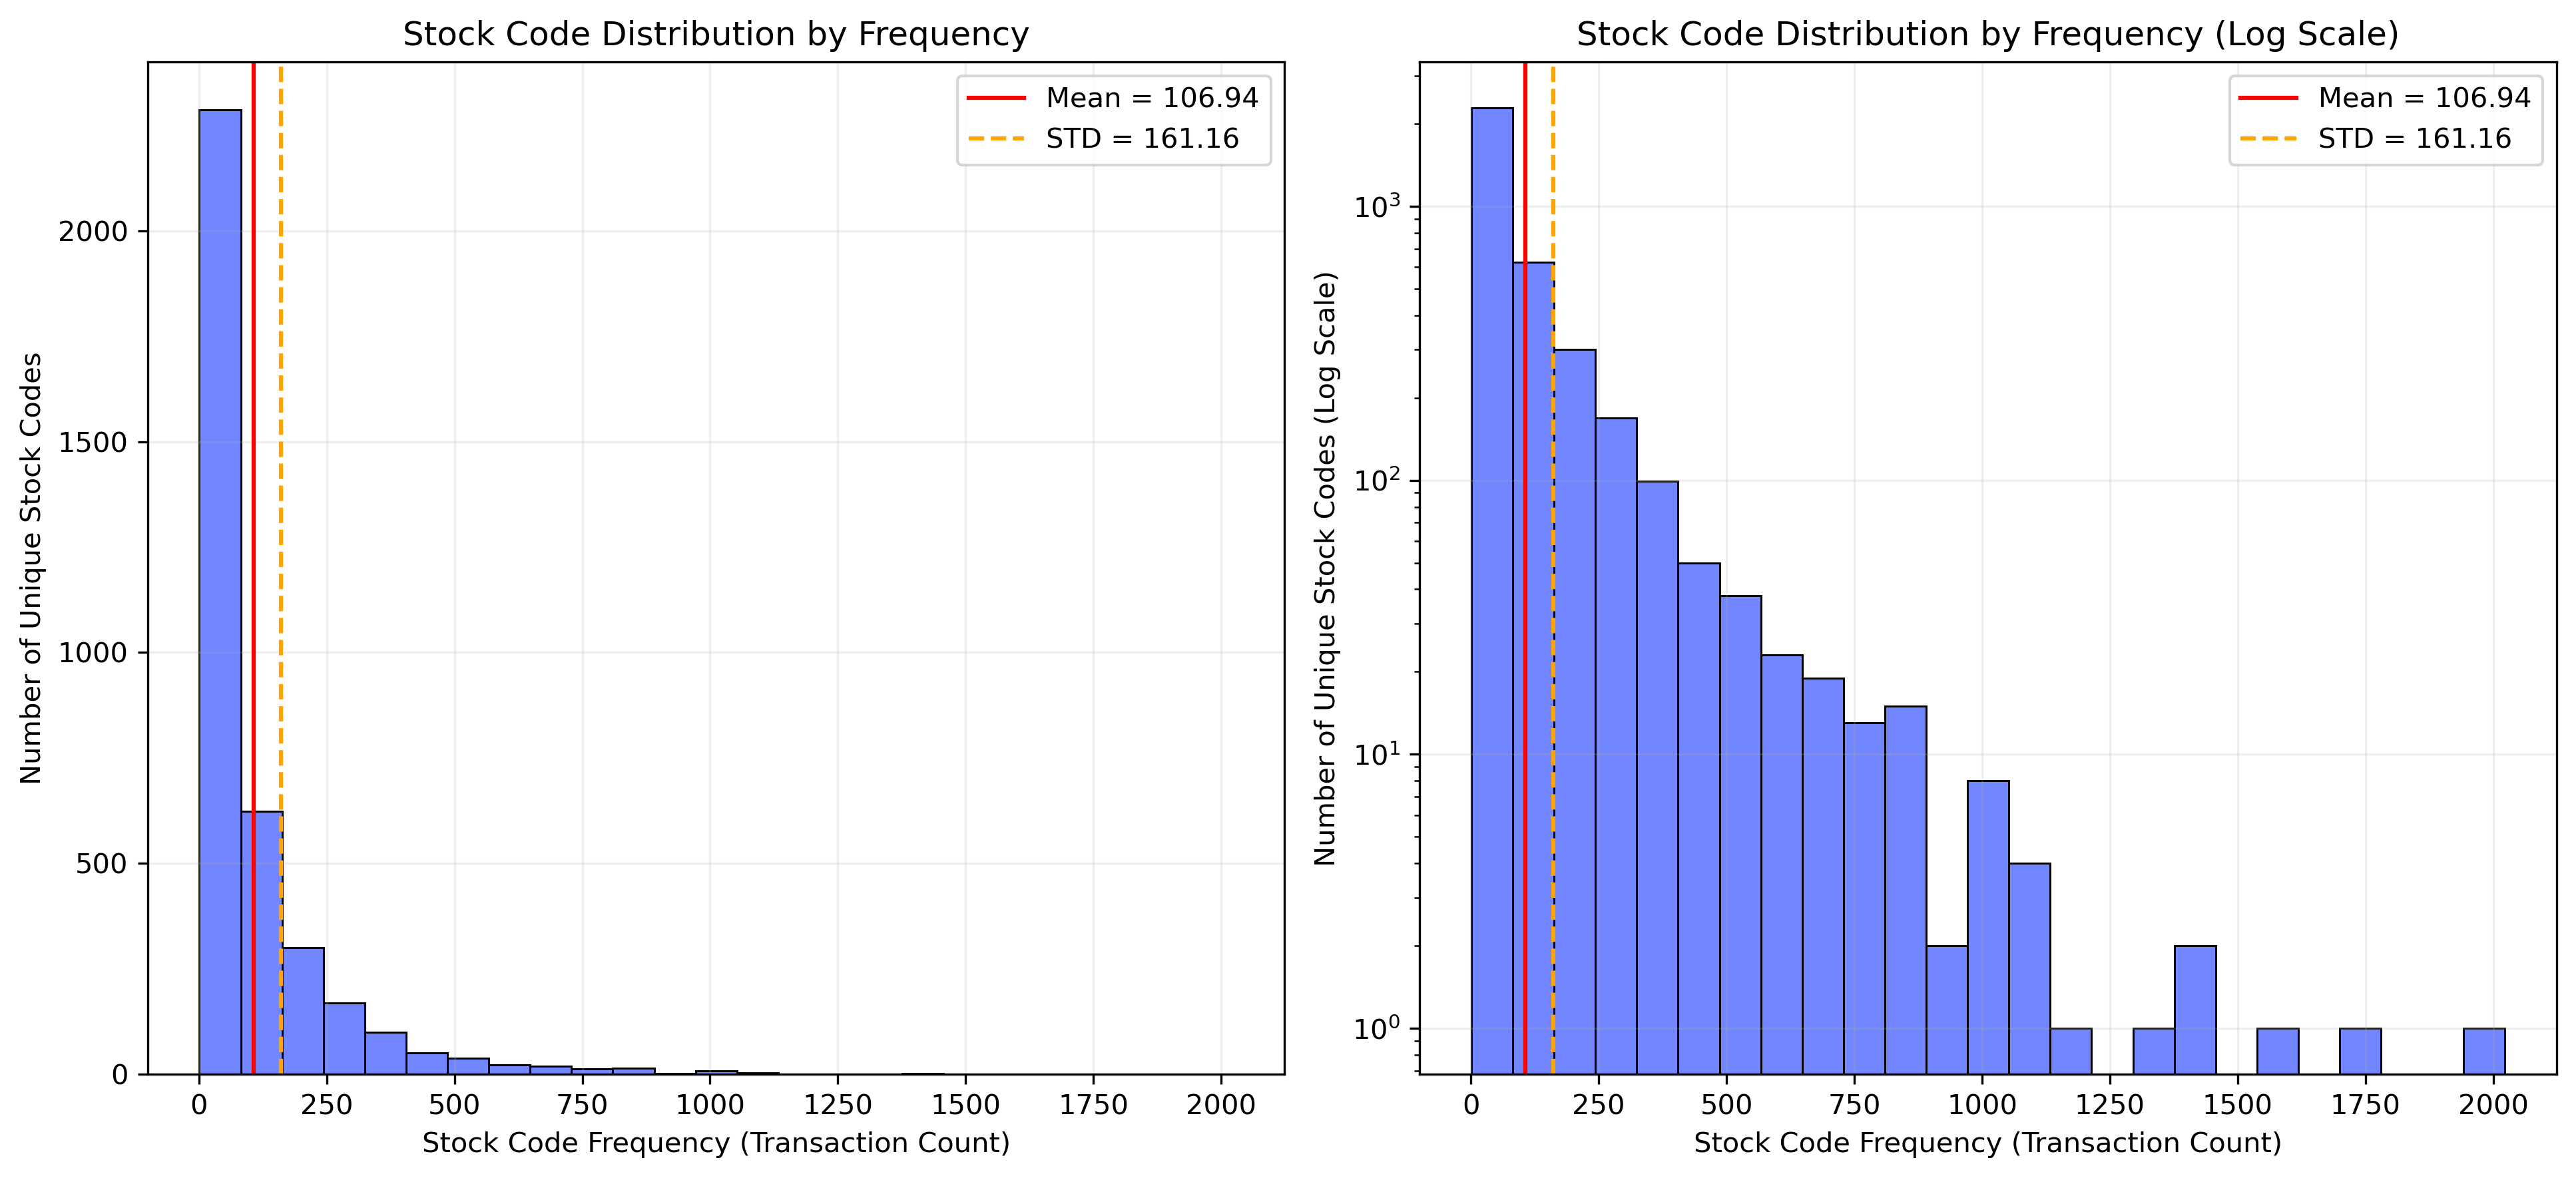

In [96]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (13, 6), dpi = 300)

#============ Plot 1 ============
sns.histplot(stock_code_counts, bins = 25, ax = ax1, color = "#415eff", edgecolor = 'black', linewidth = 0.7)
ax1.axvline(stock_code_mean, color = 'red', label = f'Mean = {stock_code_mean:.2f}')
ax1.axvline(stock_code_std, color = 'orange', ls = '--', label = f'STD = {stock_code_std:.2f}')

ax1.set_title('Stock Code Distribution by Frequency')
ax1.set_xlabel('Stock Code Frequency (Transaction Count)')
ax1.set_ylabel('Number of Unique Stock Codes')
ax1.legend()
ax1.grid(alpha = 0.2)

#============ Plot 2 ============
sns.histplot(stock_code_counts, bins = 25, ax = ax2, color = '#415eff', edgecolor = 'black', linewidth = 0.7)
ax2.axvline(stock_code_mean, color = 'red', label = f'Mean = {stock_code_mean:.2f}')
ax2.axvline(stock_code_std, color = 'orange', ls = '--', label = f'STD = {stock_code_std:.2f}')

ax2.set_yscale('log')

ax2.set_title('Stock Code Distribution by Frequency (Log Scale)')
ax2.set_xlabel('Stock Code Frequency (Transaction Count)')
ax2.set_ylabel('Number of Unique Stock Codes (Log Scale)')
ax2.legend()
ax2.grid(alpha = 0.2)


plt.tight_layout()
plt.show()

As with the *cutomer_id* data, the interquartile range, as well as the lower and upper thresholds, will be calculated to provide a more detailed assessment of the distribution. Data points that fall outside these thresholds are classified as outliers and will be winsorized. Based on the results of the winzoring, a decision will be made regarding further action to be taken with respect to the outliers.

In [97]:
stock_code_25_percentile = np.percentile(stock_code_counts, 25)
stock_code_75_percentile = np.percentile(stock_code_counts, 75)

stock_code_IQR = stock_code_75_percentile - stock_code_25_percentile

stock_code_lower_threshold = stock_code_25_percentile - (1.5 * stock_code_IQR)
stock_code_upper_threshold = stock_code_75_percentile + (1.5 * stock_code_IQR)

print("Parameters for identifying outliers")
print("\n25 percentile =", stock_code_25_percentile,
      "\n75 percentile =", stock_code_75_percentile,
      "\nIQR =", stock_code_IQR,
      "\nLower threshold =", stock_code_lower_threshold,
      "\nUpper threshold =", stock_code_upper_threshold)

Parameters for identifying outliers

25 percentile = 12.0 
75 percentile = 134.0 
IQR = 122.0 
Lower threshold = -171.0 
Upper threshold = 317.0


As the IQR was calculated. The optimal number of bins by the Freedman-Diaconis rule could be obtained.

In [98]:
bw = (2 * stock_code_IQR) / pow(len(stock_code_counts), 1/3)
stock_code_bins = (stock_code_counts.max() - stock_code_counts.min()) / bw
print (f"Optimal number of bins = {stock_code_bins:.1f}")

Optimal number of bins = 127.7


As with the POL data, the calculated number of bins $128$ is not applicable due to the long tail of the distribution. Therefore, the standard $25$ bins are used instead.

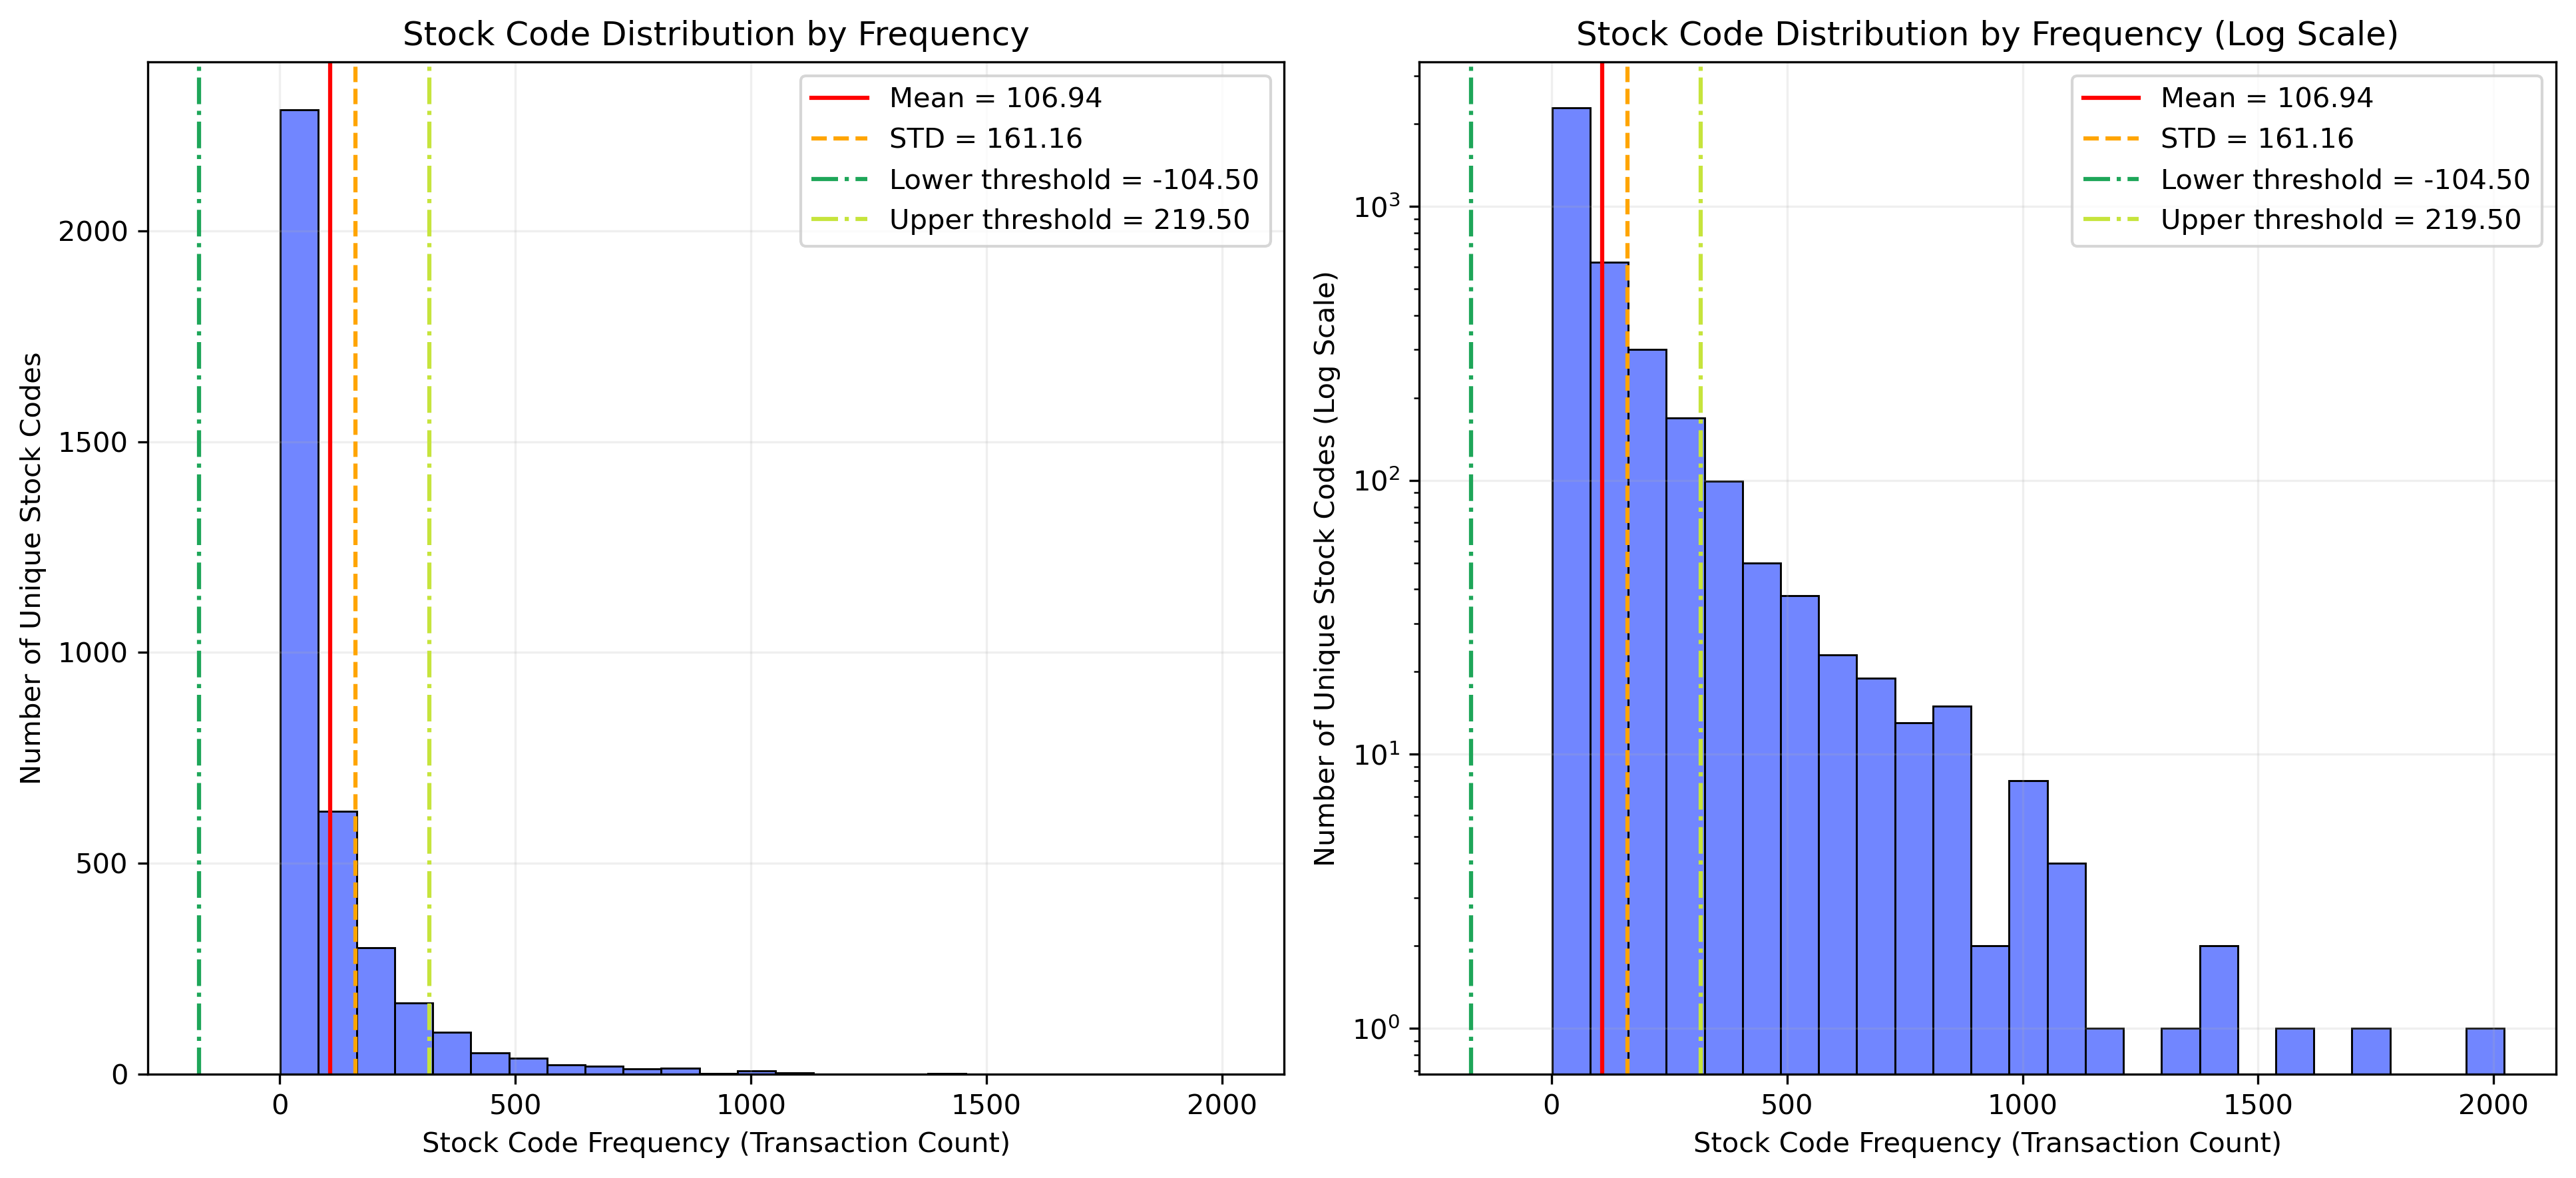

In [99]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (13, 6), dpi = 300)

#============ Plot 1 ============
sns.histplot(stock_code_counts, bins = 25, ax = ax1, color = "#415eff", edgecolor = 'black', linewidth = 0.7)
ax1.axvline(stock_code_mean, color = 'red', label = f'Mean = {stock_code_mean:.2f}')
ax1.axvline(stock_code_std, color = 'orange', ls = '--', label = f'STD = {stock_code_std:.2f}')
ax1.axvline(stock_code_lower_threshold, color = '#1ea659', ls = '-.', label = f'Lower threshold = {customer_lower_threshold:.2f}')
ax1.axvline(stock_code_upper_threshold, color = "#c6e43c", ls = '-.', label = f'Upper threshold = {customer_upper_threshold:.2f}')

ax1.set_title('Stock Code Distribution by Frequency')
ax1.set_xlabel('Stock Code Frequency (Transaction Count)')
ax1.set_ylabel('Number of Unique Stock Codes')
ax1.legend()
ax1.grid(alpha = 0.2)

#============ Plot 2 ============
sns.histplot(stock_code_counts, bins = 25, ax = ax2, color = '#415eff', edgecolor = 'black', linewidth = 0.7)
ax2.axvline(stock_code_mean, color = 'red', label = f'Mean = {stock_code_mean:.2f}')
ax2.axvline(stock_code_std, color = 'orange', ls = '--', label = f'STD = {stock_code_std:.2f}')
ax2.axvline(stock_code_lower_threshold, color = '#1ea659', ls = '-.', label = f'Lower threshold = {customer_lower_threshold:.2f}')
ax2.axvline(stock_code_upper_threshold, color = "#c6e43c", ls = '-.', label = f'Upper threshold = {customer_upper_threshold:.2f}')
ax2.set_yscale('log')

ax2.set_title('Stock Code Distribution by Frequency (Log Scale)')
ax2.set_xlabel('Stock Code Frequency (Transaction Count)')
ax2.set_ylabel('Number of Unique Stock Codes (Log Scale)')
ax2.legend()
ax2.grid(alpha = 0.2)


plt.tight_layout()
plt.show()

As is evident, the range of data between the upper and lower thresholds is relatively limited. In order to guarantee that all details are considered in the analysis, the winsorization method will also be applied in this case.

This involves replacing data points that fall outside the 5th and 95th percentiles with values that correspond to those percentiles, but as the distribution graph is right-skewed in this case, there is no need to perform lower-limit winsorization.

In [100]:
upper_limit = np.percentile(stock_code_counts, 95)

stock_code_counts_winsorized = stock_code_counts.clip(upper = upper_limit)

stock_code_counts_winsorized

stock_code
85123A    397
22423     397
85099B    397
84879     397
47566     397
         ... 
90214T      1
90214U      1
90214W      1
90214Z      1
23843       1
Name: count, Length: 3657, dtype: int64

Before plotting new graphs, the mean and median values for the updated data will be calculated.

In [101]:
stock_code_winsorized_mean = np.mean(stock_code_counts_winsorized)
stock_code_winsorized_std = np.std(stock_code_counts_winsorized)

print("mean =", stock_code_winsorized_mean, "\nstd = ", stock_code_winsorized_std)

mean = 94.50314465408805 
std =  111.29332929070473


Now, when data is winsorized, the optimal number of bins can be obtained using the Freedman–Diaconis rule:

In [102]:
bw = (2 * stock_code_IQR) / pow(len(stock_code_counts_winsorized), 1/3)
stock_code_bins = (stock_code_counts_winsorized.max() - stock_code_counts_winsorized.min()) / bw
print (f"Optimal number of bins = {stock_code_bins:.1f}")

Optimal number of bins = 25.0


Given that winsorization has relieved the outliers (extreme values) from the distribution graph, the second graph on a logarithmic scale is no longer necessary

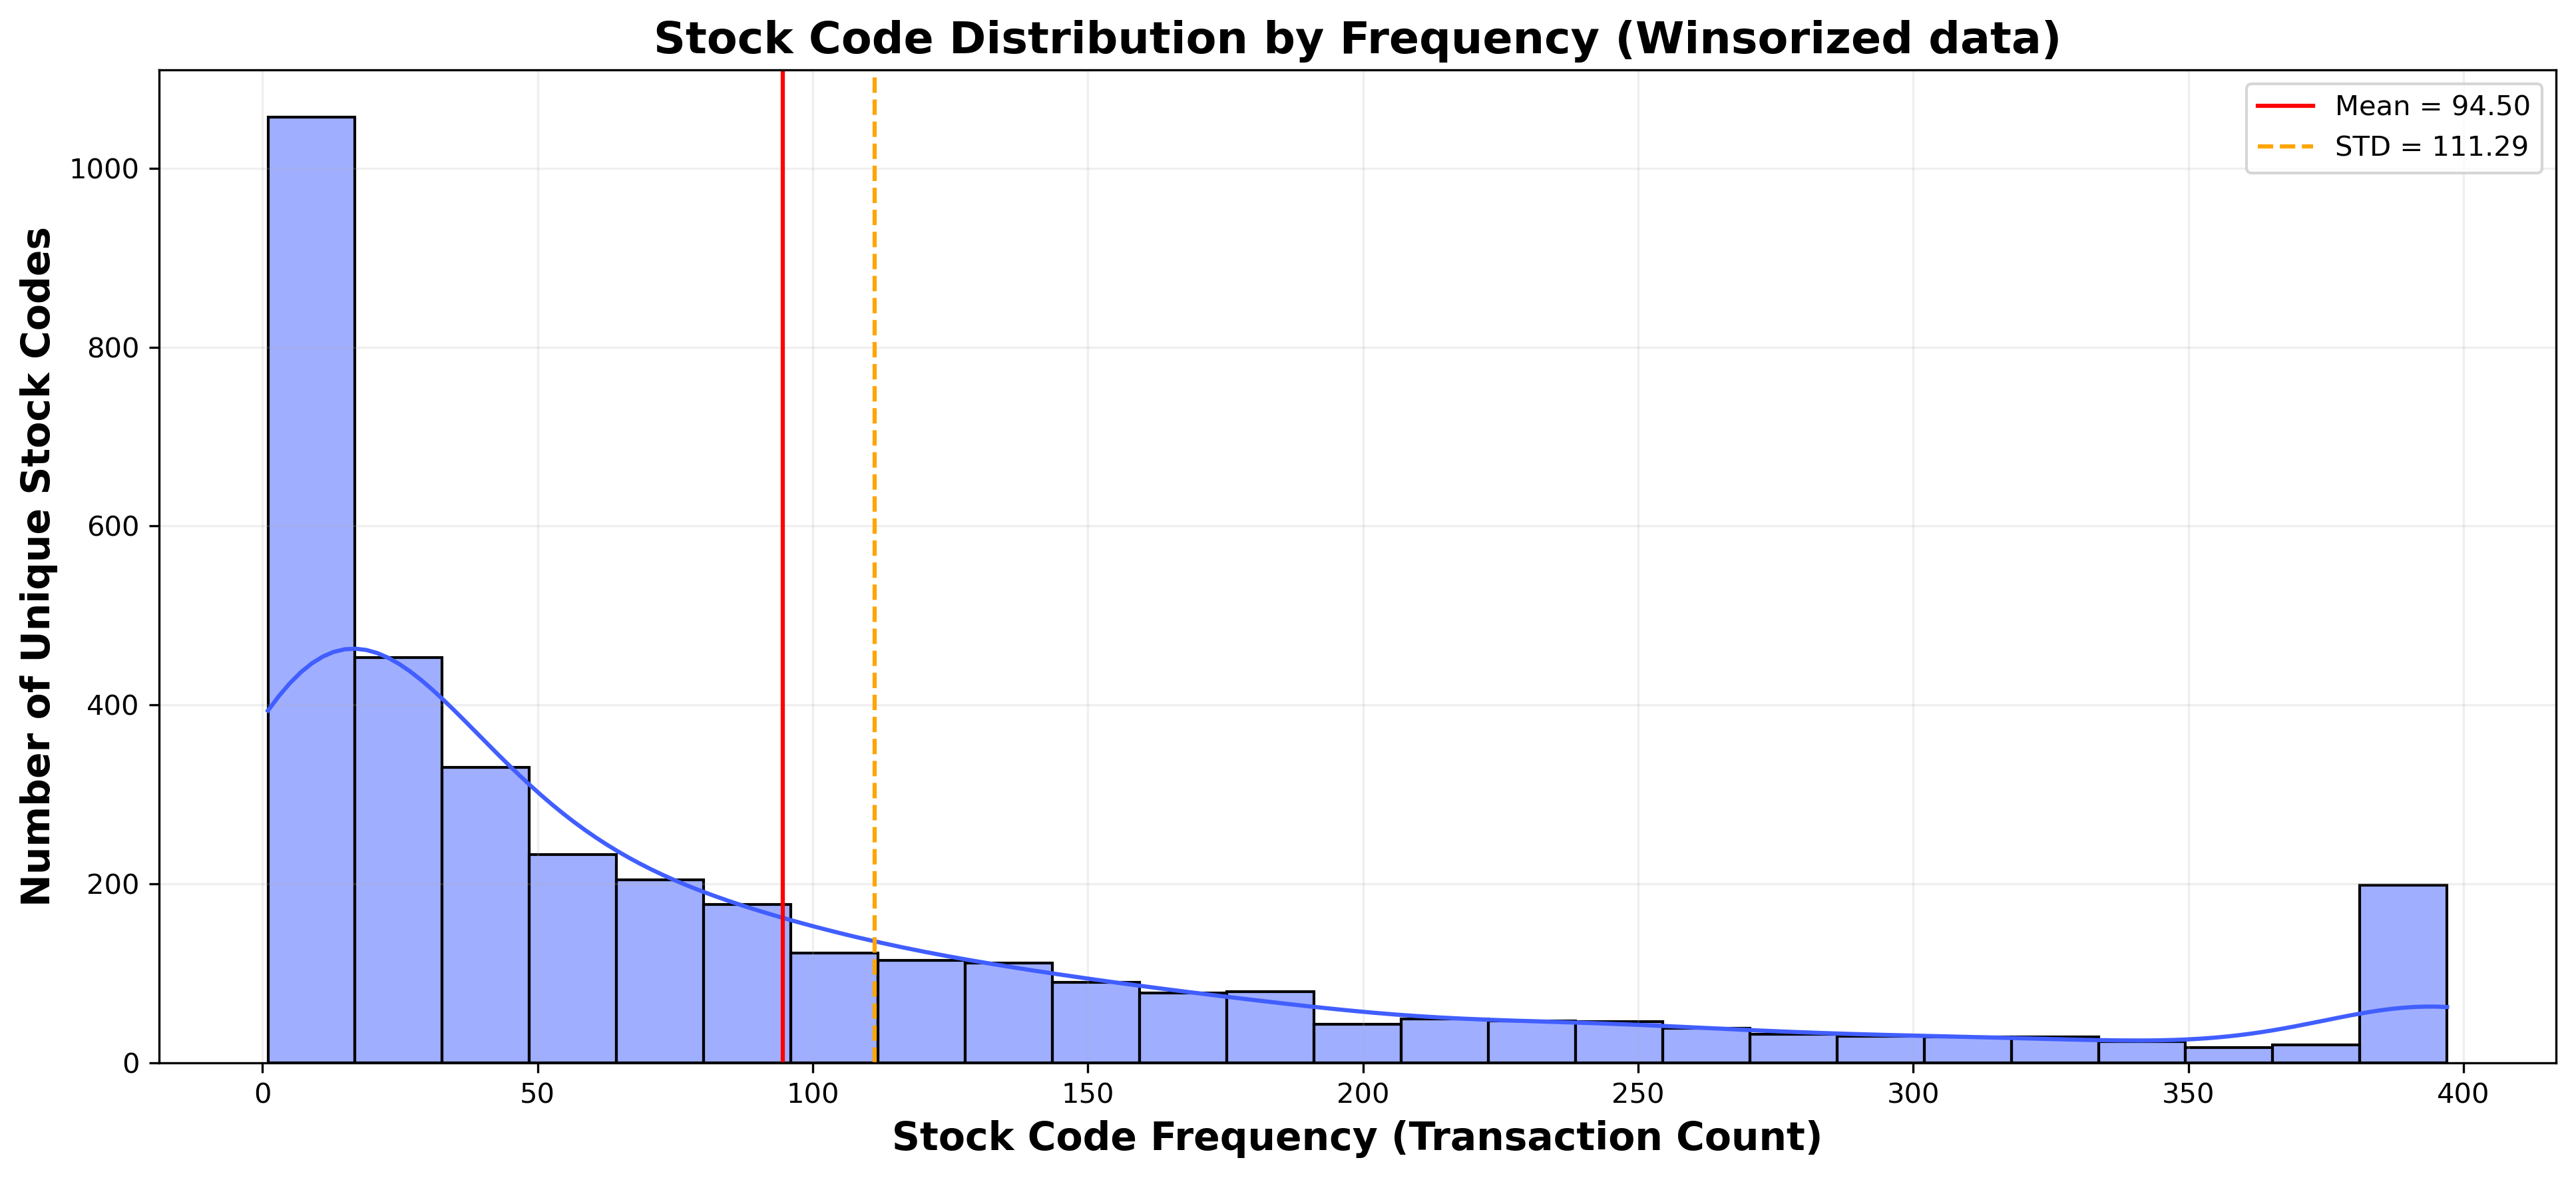

In [103]:
fig, ax = plt.subplots(figsize = (13, 6), dpi = 300)

#============ Plot 1 ==========
sns.histplot(stock_code_counts_winsorized, bins = 25, ax = ax, kde = True, color = '#415eff', edgecolor = 'black', linewidth = 1)
ax.axvline(stock_code_winsorized_mean, color = 'red', label = f'Mean = {stock_code_winsorized_mean:.2f}')
ax.axvline(stock_code_winsorized_std, color = 'orange', ls = '--', label = f'STD = {stock_code_winsorized_std:.2f}')

ax.set_title('Stock Code Distribution by Frequency (Winsorized data)', fontweight = 'bold', fontsize = 16)
ax.set_xlabel('Stock Code Frequency (Transaction Count)', fontweight = 'bold', fontsize = 14)
ax.set_ylabel('Number of Unique Stock Codes', fontweight = 'bold', fontsize = 14)
ax.legend()
ax.grid(alpha = 0.2)

plt.tight_layout()
plt.show()

Check how many users underwent the winsorization process.

In [104]:
diff_mask = stock_code_counts != stock_code_counts_winsorized
changed_count = diff_mask.sum()

print(f"Number of stock codes subjected to winsorization: {changed_count}")

Number of stock codes subjected to winsorization: 182


In order to gain a more comprehensive understanding of the impact of the winsorization procedure on the statistical parameters, a comparison will be conducted between the corrected data and the original data.

In [105]:
original_stats = stock_code_counts.describe()
winsorized_stats = stock_code_counts_winsorized.describe()

# Concatenate descriptions along columns (axis=1)
comparison_df = pd.concat([original_stats, winsorized_stats], axis=1)

comparison_df.columns = ['Original Data', 'Winsorized (95th)']
print(comparison_df)

       Original Data  Winsorized (95th)
count    3657.000000        3657.000000
mean      106.936833          94.503145
std       161.182222         111.308549
min         1.000000           1.000000
25%        12.000000          12.000000
50%        48.000000          48.000000
75%       134.000000         134.000000
max      2023.000000         397.000000


Based on the results obtained and using the new values for the mean and standard deviation, the data were successfully normalized. As a result, we were able to analyze the distribution of stock codes by demand level while retaining data on products with abnormally high demand and without removing them.

According to the demand distribution graph for specific goods, the distribution is shifted to the right (positive skewness). This result indicates that most goods are in demand among mass consumers, but there are also goods that are purchased in large quantities (which may indicate wholesale purchases).

For future customer segmentation, stock codes can be divided into the following groups based on order frequency:
- **Low demand** - 0-50;
- **Medium demand** - 50-150;
- **High demand** - 150-400;
- **Extremely high demand (or bulk purchases)** - over 400.

The final step will be to select users who have been subject to winsorization and place them into a separate dataset that can be used later.

In [106]:
stock_code_counts_winsorized_ids = stock_code_counts[stock_code_counts > upper_limit].index

stock_code_winsorized = df[df['stock_code'].isin(stock_code_counts_winsorized_ids)]
stock_code_winsorized

,invoice_number,stock_code,description,quantity,invoice_datetime,invoice_date,invoice_time,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2010-12-01,08:26:00,2.55,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,2010-12-01,08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,2010-12-01,08:34:00,1.69,13047.0,United Kingdom
12,536367,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,8,2010-12-01 08:34:00,2010-12-01,08:34:00,3.75,13047.0,United Kingdom
17,536367,21754,HOME BUILDING BLOCK WORD,3,2010-12-01 08:34:00,2010-12-01,08:34:00,5.95,13047.0,United Kingdom
...,...,...,...,...,...,...,...,...,...,...
391058,581587,22726,ALARM CLOCK BAKELIKE GREEN,4,2011-12-09 12:50:00,2011-12-09,12:50:00,3.75,12680.0,France
391059,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,2011-12-09 12:50:00,2011-12-09,12:50:00,3.75,12680.0,France
391060,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8,2011-12-09 12:50:00,2011-12-09,12:50:00,1.95,12680.0,France
391061,581587,22629,SPACEBOY LUNCH BOX,12,2011-12-09 12:50:00,2011-12-09,12:50:00,1.95,12680.0,France


In [107]:
total_stock_code_winsorized = stock_code_winsorized.shape[0]
percentage_stock_code_winsorized = float((total_stock_code_winsorized / df.shape[0]) * 100)

print(f"\nNumber of records based on 'stock_id' underwent the winsorization process {total_stock_code_winsorized} ({percentage_stock_code_winsorized:.2f}%) records")


Number of records based on 'stock_id' underwent the winsorization process 117724 (30.10%) records


The following results were obtained from an analysis of the distribution of parameter `stock_code`:
1. The records of $182$ transactions was smoothed out using Winsorisation. This is due to the fact that the number of transactions involving these particular products was significantly higher than for the other products included in the dataset.
2. These $182$ stock codes account for $117724\ (30.10\%)$ transaction records in the dataset.

The obtained dataset of stock codes with high order frequency should be saved in a separate file for future use or deeper sub-EDA analysis.

In [108]:
stock_code_winsorized.to_csv(processed_data_directory_path / "e-commerce-data-winsorized-stock-code-frequency.csv", index = False)

### 3.1.3. Distribution of `country`

In this step, the analysis is conducted to determine how orders are distributed by country. In the second step, it was found that the majority of orders originate from the United Kingdom; the geographical distribution of the data will now be examined in greater detail.

Firstly, a total order figure is calculated for each country.

In [109]:
idx = df['country'].value_counts()
country_counts = idx.reset_index()
country_counts.columns = ['country', 'order_volume']
country_counts.head(10)

,country,order_volume
0,United Kingdom,348791
1,Germany,8642
2,France,8019
3,EIRE,7126
4,Spain,2417
5,Netherlands,2322
6,Belgium,1935
7,Switzerland,1810
8,Portugal,1416
9,Australia,1180


As can be seen, there is a significant difference between Germany, which ranks second in terms of the number of orders, and the United Kingdom, which ranks first. Because of this difference, analyzing and presenting the data can be complicated. Therefore, the next step is to normalize the data by presenting the number of orders on a logarithmic scale and as a percentage.

In [110]:
# Add log order volume columns
country_counts['log_order_volume'] = np.log10(country_counts['order_volume'])

# Add column of order volume in the percentage representation
total_orders = country_counts['order_volume'].sum()
country_counts['percentage_order_volume'] = (country_counts['order_volume'] / total_orders) * 100
country_counts['percentage_order_volume'] = country_counts['percentage_order_volume'].round(2)

# Fix non-standard names
country_counts['country'] = country_counts['country'].replace({
    'EIRE': 'Ireland',
    'RSA': 'South Africa'
})

country_counts

,country,order_volume,log_order_volume,percentage_order_volume
0,United Kingdom,348791,5.542565,89.19
1,Germany,8642,3.936614,2.21
2,France,8019,3.904120,2.05
3,Ireland,7126,3.852846,1.82
4,Spain,2417,3.383277,0.62
5,Netherlands,2322,3.365862,0.59
6,Belgium,1935,3.286681,0.49
7,Switzerland,1810,3.257679,0.46
8,Portugal,1416,3.151063,0.36
9,Australia,1180,3.071882,0.30


Once the data has been normalized, the next step is to visualize the number of orders by country. As a visualization method, a map chart and a bar chart showing the top 10 countries by number of orders were chosen.

In [111]:
# 1. Create a 1-row, 2-column layout (Map on left, Bar on right)
fig = make_subplots(
    rows = 1, cols = 2,
    column_width = [0.6, 0.4],
    specs = [[{"type": "choropleth"}, {"type": "xy"}]],
    subplot_titles = ("Geographic Distribution", "Top 10 Markets (Order Volume)")
)

# 2. Add the Map Trace
fig.add_trace(
    go.Choropleth(
        locations = country_counts['country'],
        locationmode = 'country names',
        z = country_counts['log_order_volume'],
        colorscale = 'agsunset',
        colorbar = dict(
            title = {'text': "Order Volume (Log Scale)", 'side': 'top'},
            x = -0.01,           
            xanchor = 'right', 
        )
    ),
    row = 1, col = 1
)

# 3. Add the Bar Chart Trace (Top 10 for readability)
top_10 = country_counts.head(10)
bar_labels = [f"{v:,}<br>({p}%)" for v, p in zip(top_10['order_volume'], top_10['percentage_order_volume'])]
fig.add_trace(
    go.Bar(
        x = top_10['country'],
        y = top_10['order_volume'],
        text = bar_labels,
        textposition = 'outside',
        marker_color = "#6f5de5"
    ),
    row = 1, col = 2
)

# 4. Final Layout Styling
fig.update_layout(
    title={
        'text': "Global E-Commerce Activity Overview",
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 24}
    },
    template = "plotly_white",
    width = 1600,
    height = 900,
)

fig.show()

It is evident that while orders originate from various countries (37 in total), we can discern that:
1) The primary market is the United Kingdom.
2) The secondary market comprises European countries.
3) The remaining small percentage of sales is generated from all other countries.

As part of the customer segmentation project, the binary parameter “Country: United Kingdom?” can be included. Alternatively, all three parameters suggested above could be included, but the practical feasibility of this approach should be evaluated.

It would also be useful to examine the distribution of orders among countries, excluding the United Kingdom.

In [112]:
country_counts_UK = country_counts[country_counts['country'] != 'United Kingdom']

fig = make_subplots(
    rows = 1, cols = 2,
    column_width = [0.6, 0.4],
    specs = [[{"type": "choropleth"}, {"type": "xy"}]],
    subplot_titles = ("Geographic Distribution", "Top 10 Markets (Order Volume)")
)

fig.add_trace(
    go.Choropleth(
        locations = country_counts_UK['country'],
        locationmode = 'country names',
        z = country_counts_UK['order_volume'],
        colorscale = 'agsunset',
        colorbar = dict(
            title = {'text': "Order Volume", 'side': 'top'},
            x = -0.01,           
            xanchor = 'right', 
        )
    ),
    row = 1, col = 1
)

top_10 = country_counts_UK.head(10)
bar_labels = [f"{v:,}<br>({p}%)" for v, p in zip(top_10['order_volume'], top_10['percentage_order_volume'])]
fig.add_trace(
    go.Bar(
        x = top_10['country'],
        y = top_10['order_volume'],
        text = bar_labels,
        textposition = 'outside',
        marker_color = "#6f5de5"
    ),
    row = 1, col = 2
)

fig.update_layout(
    title={
        'text': "E-Commerce Activity Overview (UK Excluded)",
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 24}
    },
    template="plotly_white",
    width=1600,
    height=900,
)

fig.show()

The results indicate that the assumption that Europe is the second-largest market is valid.

### 3.1.4. Distribution of `invoice_date` and `invoice_time`

At this stage, customer activity and demand for specific products are analyzed over time. For a more detailed analysis, data such as `year`, `month`, `month_name`, and `day_of_week` are extracted from the `invoice_datetime` column.

In [113]:
df_time = df
df_time['invoice_datetime'] = pd.to_datetime(df['invoice_datetime'])

df_time['year'] = df['invoice_datetime'].dt.year

df_time['month'] = df['invoice_datetime'].dt.month
df_time['month_name'] = df['invoice_datetime'].dt.month_name()

#df_time['day_of_week'] = df['invoice_datetime'].dt.day_name()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_time['day_of_week'] = pd.Categorical(
    df_time['invoice_datetime'].dt.day_name(),
    categories = days_order,
    ordered = True
)

df_time.head()

,invoice_number,stock_code,description,quantity,invoice_datetime,invoice_date,invoice_time,unit_price,customer_id,country,year,month,month_name,day_of_week
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2010-12-01,08:26:00,2.55,17850.0,United Kingdom,2010,12,December,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,2010-12-01,08:26:00,3.39,17850.0,United Kingdom,2010,12,December,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2010-12-01,08:26:00,2.75,17850.0,United Kingdom,2010,12,December,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,2010-12-01,08:26:00,3.39,17850.0,United Kingdom,2010,12,December,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,2010-12-01,08:26:00,3.39,17850.0,United Kingdom,2010,12,December,Wednesday


In [114]:
df_time['month_name'].describe(include = 'object').T

count       391068
unique          12
top       November
freq         62911
Name: month_name, dtype: object

A preliminary analysis shows that November is the active month.
Furthermore, since it is known that the data collected covers the period from $2010$ to $2011$. The next step shows how the number of orders is distributed between these two years.

In [115]:
year_distribution = (
    df_time.groupby(['year'])['invoice_number']
    .nunique()
    .reset_index()
    .sort_values('year')
)
year_distribution

,year,invoice_number
0,2010,1394
1,2011,17005


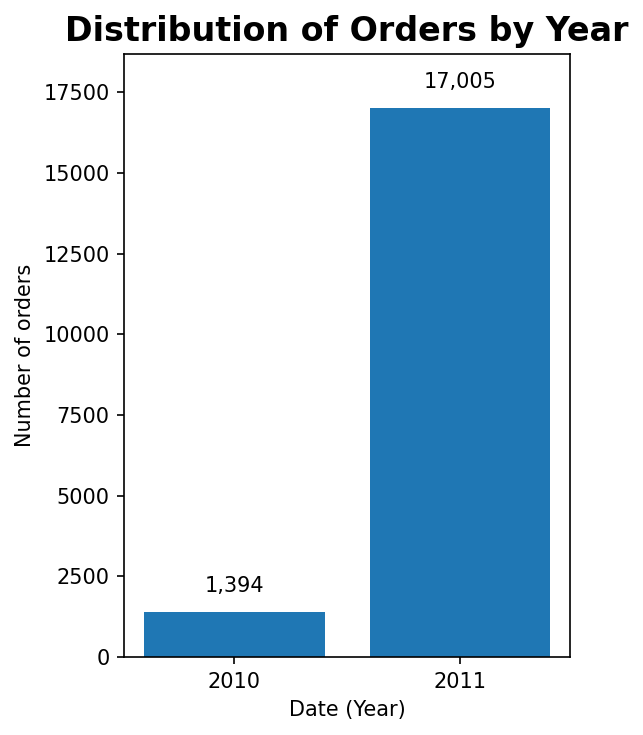

In [116]:
fig, ax = plt.subplots(figsize = (4, 5), dpi = 150)

year_distribution['year'] = year_distribution['year'].astype(str)

bars = ax.bar(year_distribution['year'], 
              year_distribution['invoice_number'])

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 500,
        f'{int(height):,}',
        ha = 'center',
        va = 'bottom'
    )

ax.set_ylim(0, year_distribution['invoice_number'].max() * 1.1)

plt.title('Distribution of Orders by Year', fontsize = 16, fontweight = 'bold')
plt.xlabel('Date (Year)')
plt.ylabel('Number of orders')
plt.tight_layout(),
plt.show()

In [117]:
month_distribution_2010 = (
    df_time[df_time['year'] == 2010]
    .groupby(['month', 'month_name'])['invoice_number']
    .nunique()
    .reset_index()
    .sort_values('month')
)
month_distribution_2010['percentage'] = (month_distribution_2010['invoice_number'] / month_distribution_2010['invoice_number'].sum() * 100)

month_distribution_2010

,month,month_name,invoice_number,percentage
0,12,December,1394,100.0


As can be seen from the results, the data mainly covers only $2011$ and just one month (December) of $2010$. The next step is to analyze the distribution of order volume by month, both for $2011$ alone and in combination with December $2010$.

In [129]:
month_distribution_2011 = (
    df_time[df_time['year'] == 2011]
    .groupby(['month', 'month_name'])['invoice_number']
    .nunique()
    .reset_index()
    .sort_values('month')
)

month_distribution_2011['percentage'] = (month_distribution_2011['invoice_number'] / month_distribution_2011['invoice_number'].sum() * 100)
month_distribution_2011['percentage'] = month_distribution_2011['percentage'].round(2)

month_distribution_2011

,month,month_name,invoice_number,percentage
0,1,January,983,5.78
1,2,February,992,5.83
2,3,March,1312,7.72
3,4,April,1139,6.70
4,5,May,1544,9.08
5,6,June,1390,8.17
6,7,July,1321,7.77
7,8,August,1267,7.45
8,9,September,1739,10.23
9,10,October,1902,11.18


In [130]:
month_distribution_all_years = (
    df_time.groupby(['month', 'month_name'])['invoice_number']
    .nunique()
    .reset_index()
    .sort_values('month')
)

month_distribution_all_years['percentage'] = (month_distribution_all_years['invoice_number'] / month_distribution_all_years['invoice_number'].sum() * 100)
month_distribution_all_years['percentage'] = month_distribution_all_years['percentage'].round(2)

month_distribution_all_years

,month,month_name,invoice_number,percentage
0,1,January,983,5.34
1,2,February,992,5.39
2,3,March,1312,7.13
3,4,April,1139,6.19
4,5,May,1544,8.39
5,6,June,1390,7.55
6,7,July,1321,7.18
7,8,August,1267,6.89
8,9,September,1739,9.45
9,10,October,1902,10.34


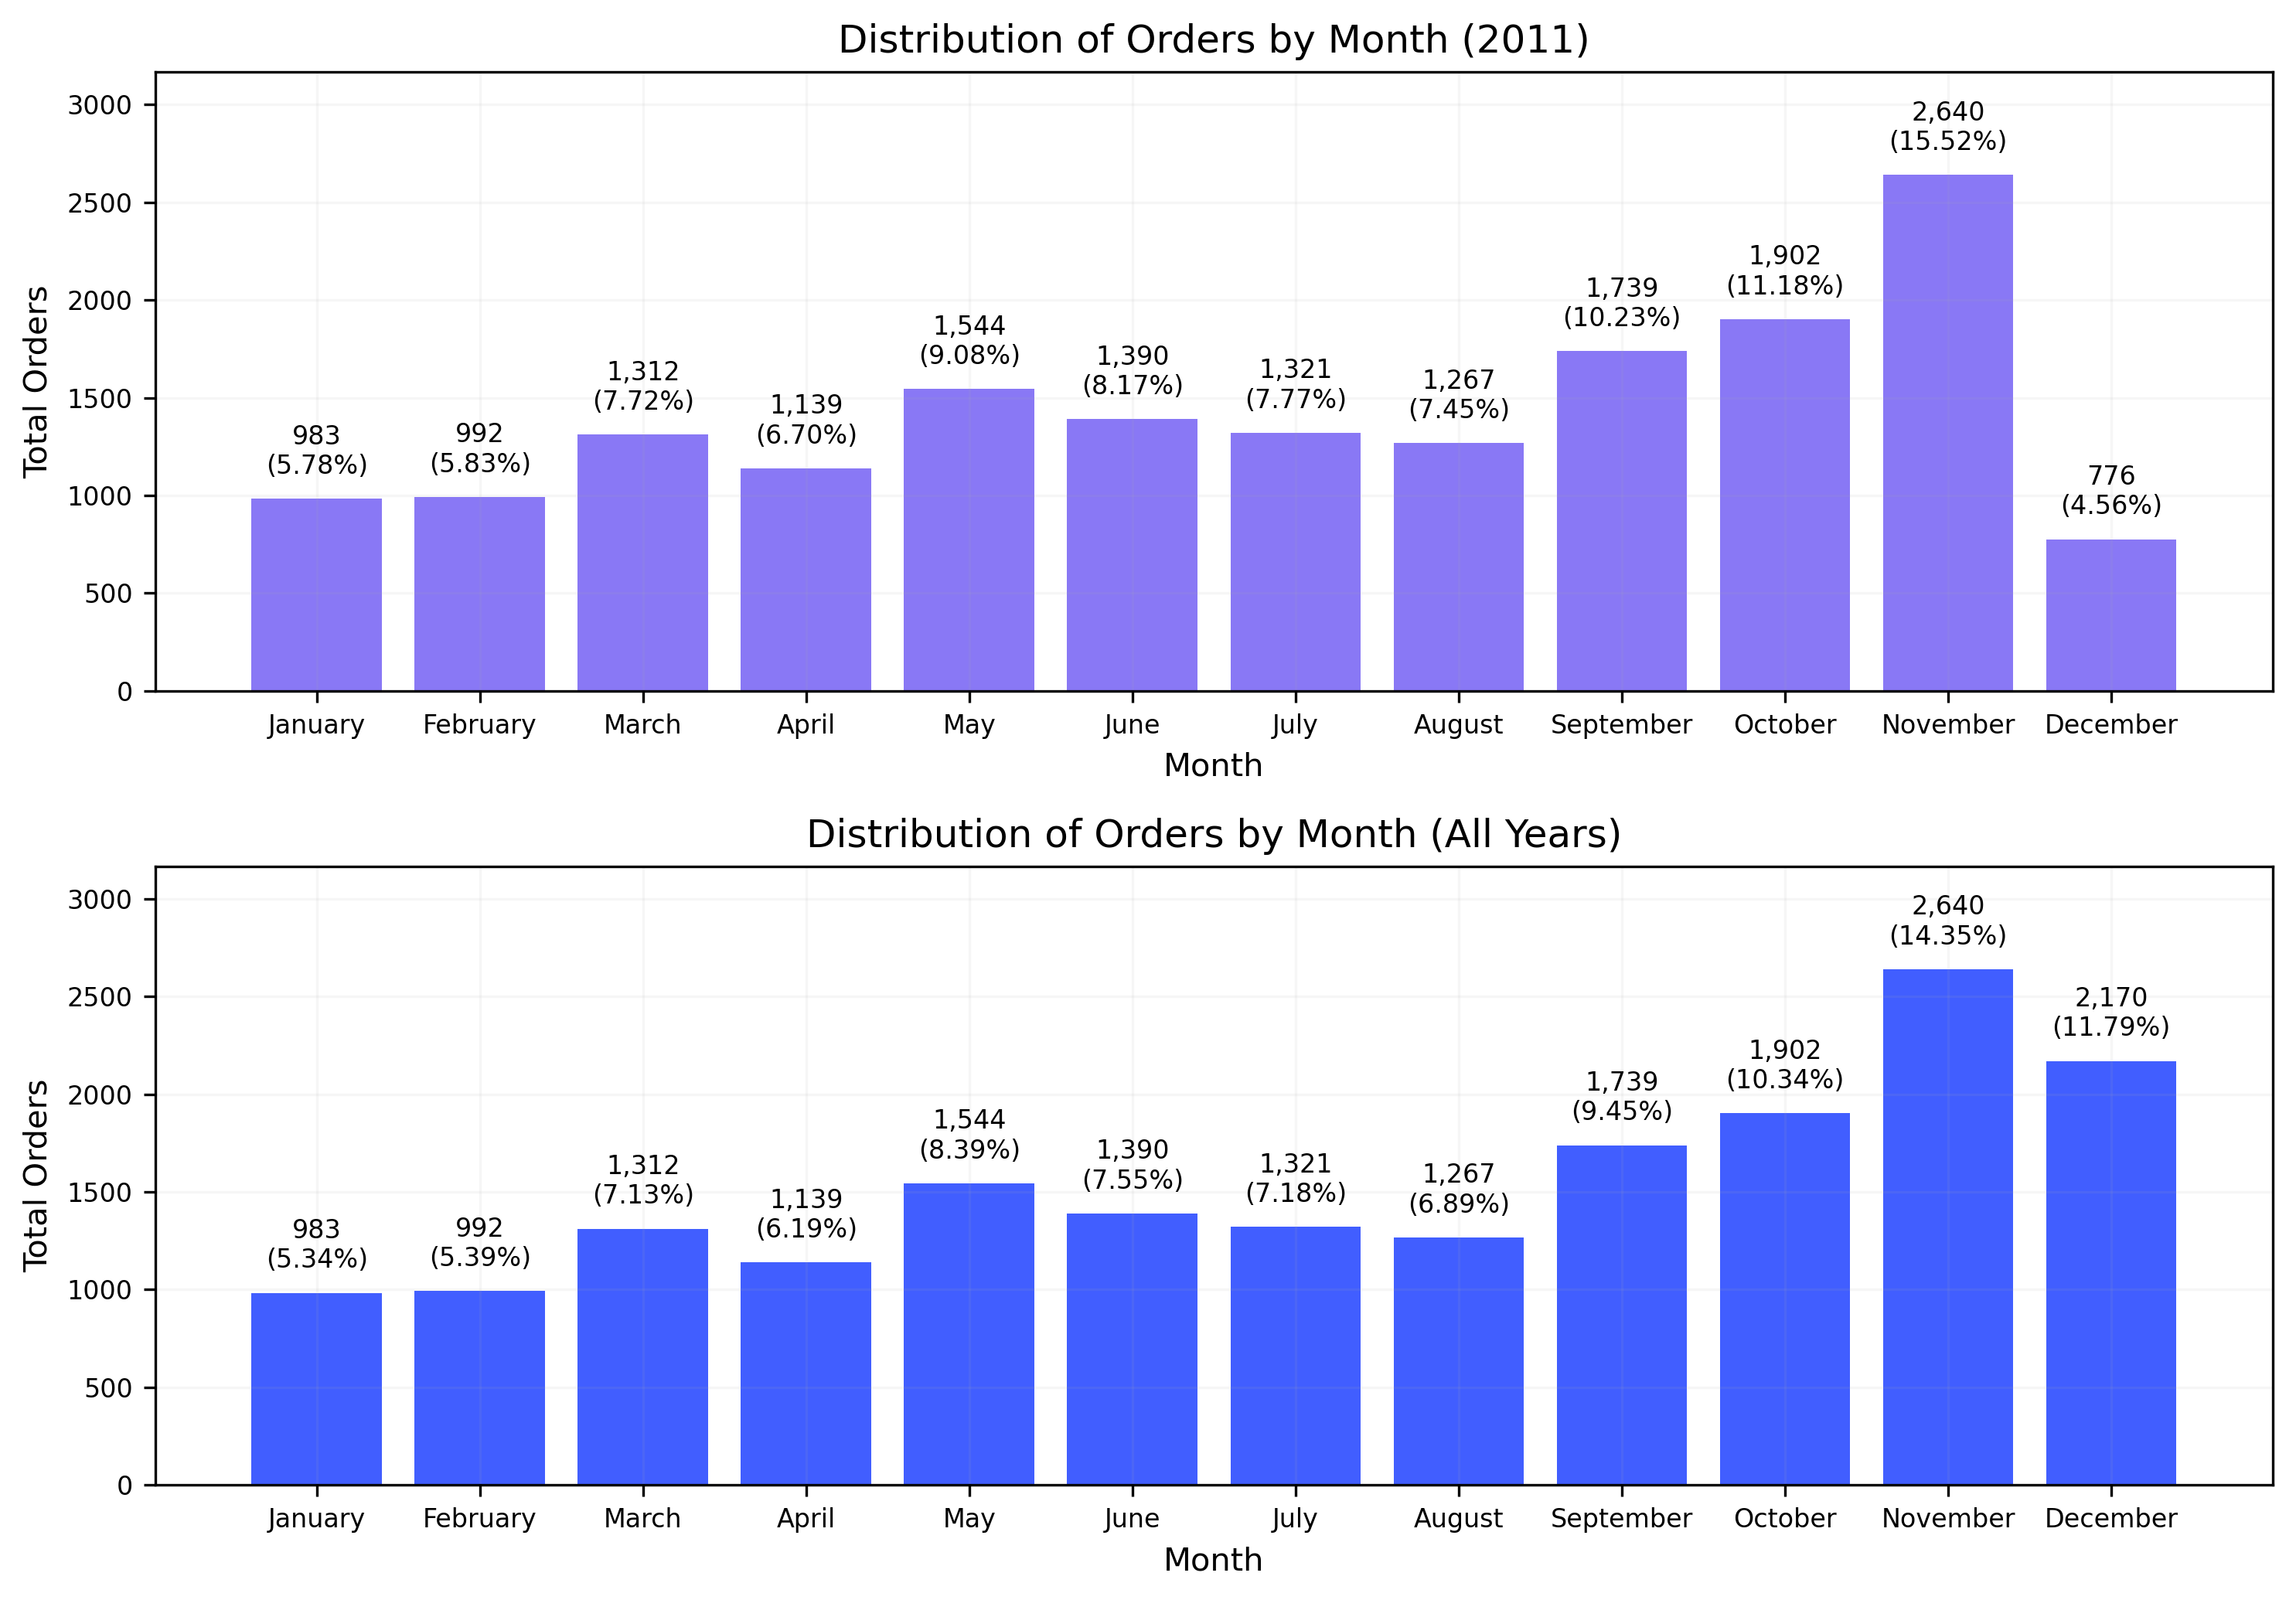

In [131]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (10, 7), dpi = 300)

## PLot 1
bars1 = ax1.bar(
    month_distribution_2011['month_name'],
    month_distribution_2011['invoice_number'],
    color = '#8978f5'
)

for bar, value, pct in zip(
    bars1,
    month_distribution_2011['invoice_number'],
    month_distribution_2011['percentage'],
):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{value:,}\n({pct:.2f}%)',
        ha='center',
        va='bottom',
        fontsize = 8
    )

ax1.set_ylim(0, month_distribution_2011['invoice_number'].max() * 1.2)

ax1.set_title('Distribution of Orders by Month (2011)', fontsize = 12)
ax1.set_xlabel('Month', fontsize = 10)
ax1.set_ylabel('Total Orders', fontsize = 10)
ax1.grid(alpha = 0.1)
ax1.tick_params(axis='both', labelsize = 8)

## PLot 2
bars2 = ax2.bar(
    month_distribution_all_years['month_name'],
    month_distribution_all_years['invoice_number'],
    color = '#415eff'
)

for bar, value, pct in zip(
    bars2,
    month_distribution_all_years['invoice_number'],
    month_distribution_all_years['percentage'],
):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{value:,}\n({pct:.2f}%)',
        ha='center',
        va='bottom',
        fontsize = 8
    )

ax2.set_ylim(0, month_distribution_2011['invoice_number'].max() * 1.2)

ax2.set_title('Distribution of Orders by Month (All Years)', fontsize = 12)
ax2.set_xlabel('Month', fontsize = 10)
ax2.set_ylabel('Total Orders', fontsize = 10)
ax2.grid(alpha = 0.1)
ax2.tick_params(axis='both', labelsize = 8)

plt.tight_layout()
plt.show()

The results show that one of the busiest periods of the year is the fourth quarter. Given that the data for $2010$ includes only December, this fact does not distort the final monthly breakdown of orders for the entire year. The increase in activity during the fourth quarter can be attributed to the holiday season, which drives strong demand for goods as gifts, as well as increased demand due to holiday discounts and promotions.

The next step is to analyze the distribution of order frequency by day of the week. The procedure is carried out in the same way as the analysis by month. Since the data for $2010$ do not significantly distort the analysis or introduce noise, they will be included immediately without prior separation.

In [127]:
day_distribution_all_years = (
    df_time.groupby('day_of_week')['invoice_number']
    .nunique()
    .reset_index()
    .sort_values('day_of_week')
)

day_distribution_all_years['percentage'] = (day_distribution_all_years['invoice_number'] / day_distribution_all_years['invoice_number'].sum() * 100)
day_distribution_all_years['percentage'] = day_distribution_all_years['percentage'].round(2)

day_distribution_all_years

,day_of_week,invoice_number,percentage
0,Monday,2830,15.38
1,Tuesday,3156,17.15
2,Wednesday,3434,18.66
3,Thursday,4003,21.76
4,Friday,2808,15.26
5,Sunday,2168,11.78


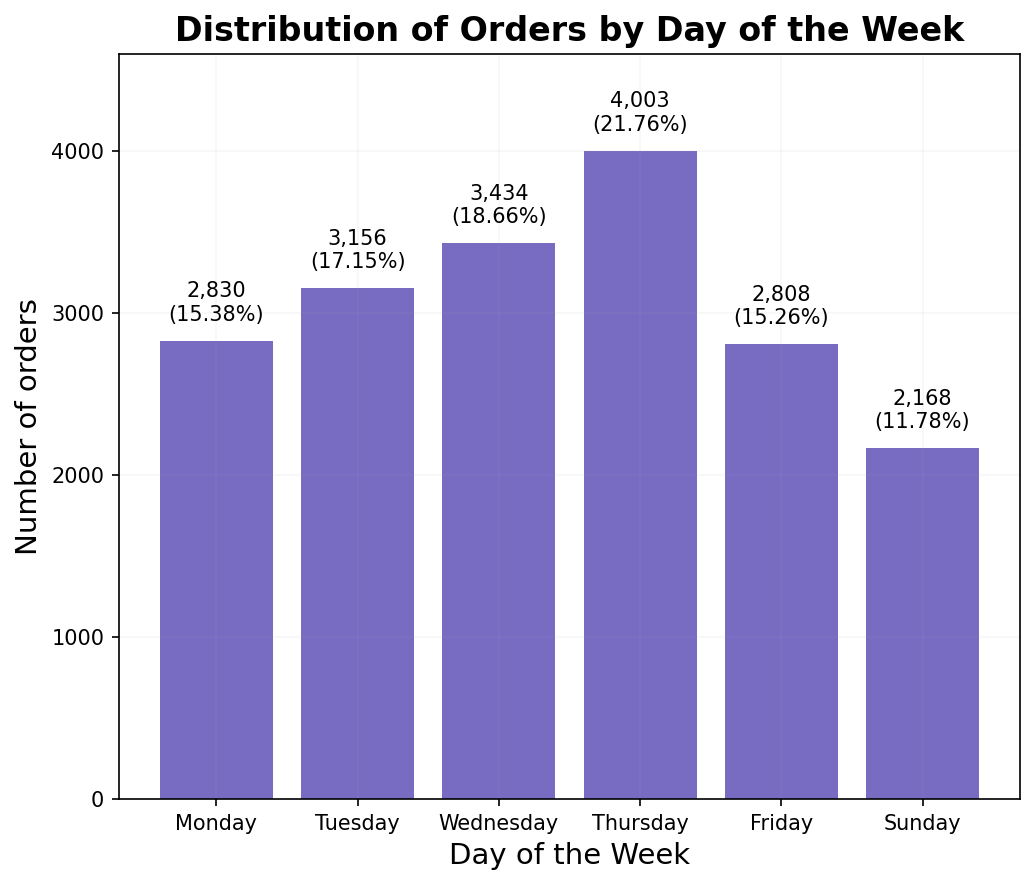

In [157]:
fig, ax = plt.subplots(figsize = (7, 6), dpi = 150)

bars = ax.bar(day_distribution_all_years['day_of_week'],
              day_distribution_all_years['invoice_number'],
              color = "#776bc2"
)

for bar, value, pct in zip(
    bars,
    day_distribution_all_years['invoice_number'],
    day_distribution_all_years['percentage'],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{value:,}\n({pct:.2f}%)',
        ha='center',
        va='bottom',
        fontsize = 10
    )

ax.set_ylim(0, day_distribution_all_years['invoice_number'].max() * 1.15)

plt.title('Distribution of Orders by Day of the Week', fontsize = 16, fontweight = 'bold')
plt.xlabel('Day of the Week', fontsize = 14)
plt.ylabel('Number of orders', fontsize = 14)

ax.grid(alpha = 0.1)
plt.tight_layout(),
plt.show()

When devided date/time column, answer for:
- Seasonality: Which months have the highest sales?
- Weekly Patterns: Do customers shop more on weekends?
- Daily Cycles: What is the "peak hour" for orders?

Last column for EDA
- quatity,
- unit price